# Soil eDNA Metabarcoding Pipeline Analysis
### A Reproducible Workflow for MinION Amplicon Sequencing (JEDI & COI)
**Project:** Genorobotics Semester Project (EPFL)

**Markers:** JEDI (~460 bp COI, arthropod-optimized) & Standard COI (~658 bp Folmer)

---

## 0. Critical Review: Limitations & Technical Constraints

Before presenting the biological results, it is important to note the technical limitations encountered during this project.

### 1. The JEDI Advantage: Optimized for Soil Arthropods
The JEDI primers target a ~460 bp region of the COI gene, specifically designed for arthropod detection in environmental samples. This shorter fragment is better suited for degraded soil DNA compared to the standard Folmer COI primers (~658 bp).
* **Expected Dominance:** Arthropoda (insects, collembolans, arachnids), Annelida (earthworms), and Nematoda should dominate.
* **Potential Limitation:** The shorter fragment may reduce species-level resolution compared to full-length COI.

### 2. Standard COI in Soil: Expected Challenges
The standard Folmer COI primers (~658 bp) may underperform in soil matrices:
* **DNA Degradation:** Soil humic acids degrade DNA, favoring shorter amplicons (JEDI) over longer ones (COI).
* **Primer Bias:** Folmer primers were designed for a broader metazoan range but may miss soil-specific taxa that JEDI captures.

### 3. Taxonomic Gaps and Database Limitations
* **MIDORI2 Database:** Both markers use the MIDORI2 COI reference database for SINTAX-based taxonomy. MIDORI2 appends NCBI taxon IDs to names and uses rank prefixes — these are cleaned in the code below.
* **Confidence Threshold:** A strict 0.8 confidence threshold was applied. This ensures accuracy but increases the "Unassigned" rate, especially at lower taxonomic levels.
* **Local Gaps:** The database may lack sequences for many local soil invertebrates, leading to misidentifications or "Unassigned" labels.

### 4. Clustering and Size Selection
* **95% Identity Clustering:** Because Nanopore sequencing has a raw error rate of ~5%, clustering at 95% identity prevents sequencing errors from generating false OTUs.
* **Size Filters:** JEDI reads were filtered for ~300–600 bp; COI reads for ~500–800 bp. Reads outside these ranges are likely artifacts.

## To-Do List for Future Work
* **Build a local soil reference database:** Gather COI sequences for known local soil fauna from NCBI to improve species-level identification.
* **Compare JEDI vs COI yield:** Quantify how many more reads JEDI recovers from degraded soil DNA compared to standard COI.
* **Add blocking primers:** If plant or fungal DNA dominates, blocking primers could improve arthropod detection.
* **Optimize extraction protocols:** Test different soil DNA extraction kits to maximize invertebrate DNA yield.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from pathlib import Path
from Bio import SeqIO
from matplotlib import cm

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# Define a function to clean sample names (e.g., "Sample_barcode01" -> "01")
def clean_sample_names(columns):
    return [c.replace('Sample_barcode', '').replace('Sample_', '') for c in columns]

# Auto-detect taxonomy column prefix (SILVA_ or MIDORI_)
def get_tax_prefix(df):
    for col in df.columns:
        if col.startswith("SILVA_"):
            return "SILVA"
        if col.startswith("MIDORI2_"):
            return "MIDORI2"
        if col.startswith("MIDORI_"):
            return "MIDORI"
    return "SILVA"

# MIDORI2 taxonomy cleaning
rank_prefixes = re.compile(r'^(kingdom|phylum|class|order|family|genus|species)_', re.IGNORECASE)

def clean_midori_taxonomy(df, prefix):
    """Strip rank prefixes and NCBI taxon IDs from MIDORI2 taxonomy labels."""
    ranks = ['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
    tax_levels = [f'{prefix}_{r}' for r in ranks]
    for col in tax_levels:
        if col in df.columns:
            df[col] = df[col].apply(
                lambda x: rank_prefixes.sub('', str(x)) if pd.notna(x) else x
            )
            df[col] = df[col].apply(
                lambda x: '_'.join(str(x).rsplit('_', 1)[:-1])
                if pd.notna(x) and '_' in str(x) and str(x).rsplit('_', 1)[-1].isdigit()
                else x
            )
    return df

BASE = Path("out/Soil_eDNA_JEDI_COI_14_01_26")

## Table Headers & Data Structure
Inspect the comprehensive taxonomy CSV files to verify column names and data shape.

In [2]:
# Load both datasets
df_jedi_raw = pd.read_csv(BASE / 'taxonomy_summary/comprehensive_taxonomy_JEDI.csv')
df_coi_raw = pd.read_csv(BASE / 'taxonomy_summary/comprehensive_taxonomy_COI.csv')

prefix_jedi = get_tax_prefix(df_jedi_raw)
prefix_coi = get_tax_prefix(df_coi_raw)

for label, df, pfx in [("JEDI", df_jedi_raw, prefix_jedi), ("COI", df_coi_raw, prefix_coi)]:
    print(f"\n{'='*60}")
    print(f"  {label} ({pfx} database)  —  {df.shape[0]} OTUs × {df.shape[1]} columns")
    print(f"{'='*60}")
    
    sample_cols = [c for c in df.columns if c.startswith("Sample_")]
    taxonomy_cols = [c for c in df.columns if c.startswith(f"{pfx}_") or c.startswith("NCBI_")]
    meta_cols = [c for c in df.columns if c not in sample_cols + taxonomy_cols]
    
    print(f"\nMetadata columns:  {meta_cols}")
    print(f"Sample columns:    {sample_cols}")
    print(f"Taxonomy columns:  {taxonomy_cols}")
    print(f"\nFirst 3 rows:")
    display(df.head(3))

C:\Users\ilias\AppData\Local\Temp\ipykernel_26612\3118709719.py:2: DtypeWarning: Columns (27,29,31,33,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df_jedi_raw = pd.read_csv(BASE / 'taxonomy_summary/comprehensive_taxonomy_JEDI.csv')



  JEDI (MIDORI2 database)  —  22360 OTUs × 40 columns

Metadata columns:  ['OTU_ID', 'Total_Abundance', 'Rank']
Sample columns:    ['Sample_barcode01', 'Sample_barcode02', 'Sample_barcode03', 'Sample_barcode04', 'Sample_barcode05', 'Sample_barcode11', 'Sample_barcode12', 'Sample_barcode13', 'Sample_barcode14', 'Sample_barcode15', 'Sample_barcode16', 'Sample_barcode17', 'Sample_barcode18', 'Sample_barcode19', 'Sample_barcode20', 'Sample_barcode21', 'Sample_barcode22', 'Sample_barcode23', 'Sample_barcode24', 'Sample_unclassified']
Taxonomy columns:  ['MIDORI2_Domain', 'MIDORI2_Domain_Conf', 'MIDORI2_Phylum', 'MIDORI2_Phylum_Conf', 'MIDORI2_Class', 'MIDORI2_Class_Conf', 'MIDORI2_Order', 'MIDORI2_Order_Conf', 'MIDORI2_Family', 'MIDORI2_Family_Conf', 'MIDORI2_Genus', 'MIDORI2_Genus_Conf', 'MIDORI2_Species', 'MIDORI2_Species_Conf', 'NCBI_TopHit', 'NCBI_Identity', 'NCBI_Evalue']

First 3 rows:


C:\Users\ilias\AppData\Local\Temp\ipykernel_26612\3118709719.py:3: DtypeWarning: Columns (27,29,31,33,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df_coi_raw = pd.read_csv(BASE / 'taxonomy_summary/comprehensive_taxonomy_COI.csv')


,OTU_ID,Total_Abundance,Rank,Sample_barcode01,Sample_barcode02,Sample_barcode03,Sample_barcode04,Sample_barcode05,Sample_barcode11,Sample_barcode12,...,MIDORI2_Order_Conf,MIDORI2_Family,MIDORI2_Family_Conf,MIDORI2_Genus,MIDORI2_Genus_Conf,MIDORI2_Species,MIDORI2_Species_Conf,NCBI_TopHit,NCBI_Identity,NCBI_Evalue
0,OTU_JEDI_000731,0.061947,1,0.061947,0.00,0.0,0.0,0.000000,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,OTU_JEDI_021962,0.060976,2,0.000000,0.00,0.0,0.0,0.060976,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,OTU_JEDI_020943,0.050000,3,0.000000,0.05,0.0,0.0,0.000000,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



  COI (MIDORI2 database)  —  50858 OTUs × 40 columns

Metadata columns:  ['OTU_ID', 'Total_Abundance', 'Rank']
Sample columns:    ['Sample_barcode01', 'Sample_barcode02', 'Sample_barcode03', 'Sample_barcode04', 'Sample_barcode05', 'Sample_barcode11', 'Sample_barcode12', 'Sample_barcode13', 'Sample_barcode14', 'Sample_barcode15', 'Sample_barcode16', 'Sample_barcode17', 'Sample_barcode18', 'Sample_barcode19', 'Sample_barcode20', 'Sample_barcode21', 'Sample_barcode22', 'Sample_barcode23', 'Sample_barcode24', 'Sample_unclassified']
Taxonomy columns:  ['MIDORI2_Domain', 'MIDORI2_Domain_Conf', 'MIDORI2_Phylum', 'MIDORI2_Phylum_Conf', 'MIDORI2_Class', 'MIDORI2_Class_Conf', 'MIDORI2_Order', 'MIDORI2_Order_Conf', 'MIDORI2_Family', 'MIDORI2_Family_Conf', 'MIDORI2_Genus', 'MIDORI2_Genus_Conf', 'MIDORI2_Species', 'MIDORI2_Species_Conf', 'NCBI_TopHit', 'NCBI_Identity', 'NCBI_Evalue']

First 3 rows:


,OTU_ID,Total_Abundance,Rank,Sample_barcode01,Sample_barcode02,Sample_barcode03,Sample_barcode04,Sample_barcode05,Sample_barcode11,Sample_barcode12,...,MIDORI2_Order_Conf,MIDORI2_Family,MIDORI2_Family_Conf,MIDORI2_Genus,MIDORI2_Genus_Conf,MIDORI2_Species,MIDORI2_Species_Conf,NCBI_TopHit,NCBI_Identity,NCBI_Evalue
0,OTU_COI_000813,0.187124,1,0.000000,0.0,0.000000,0.0,0.184679,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,OTU_COI_000266,0.151618,2,0.127912,0.0,0.016154,0.0,0.000217,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,OTU_COI_000722,0.127011,3,0.000000,0.0,0.000000,0.0,0.124566,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Confidence Distribution Dashboard

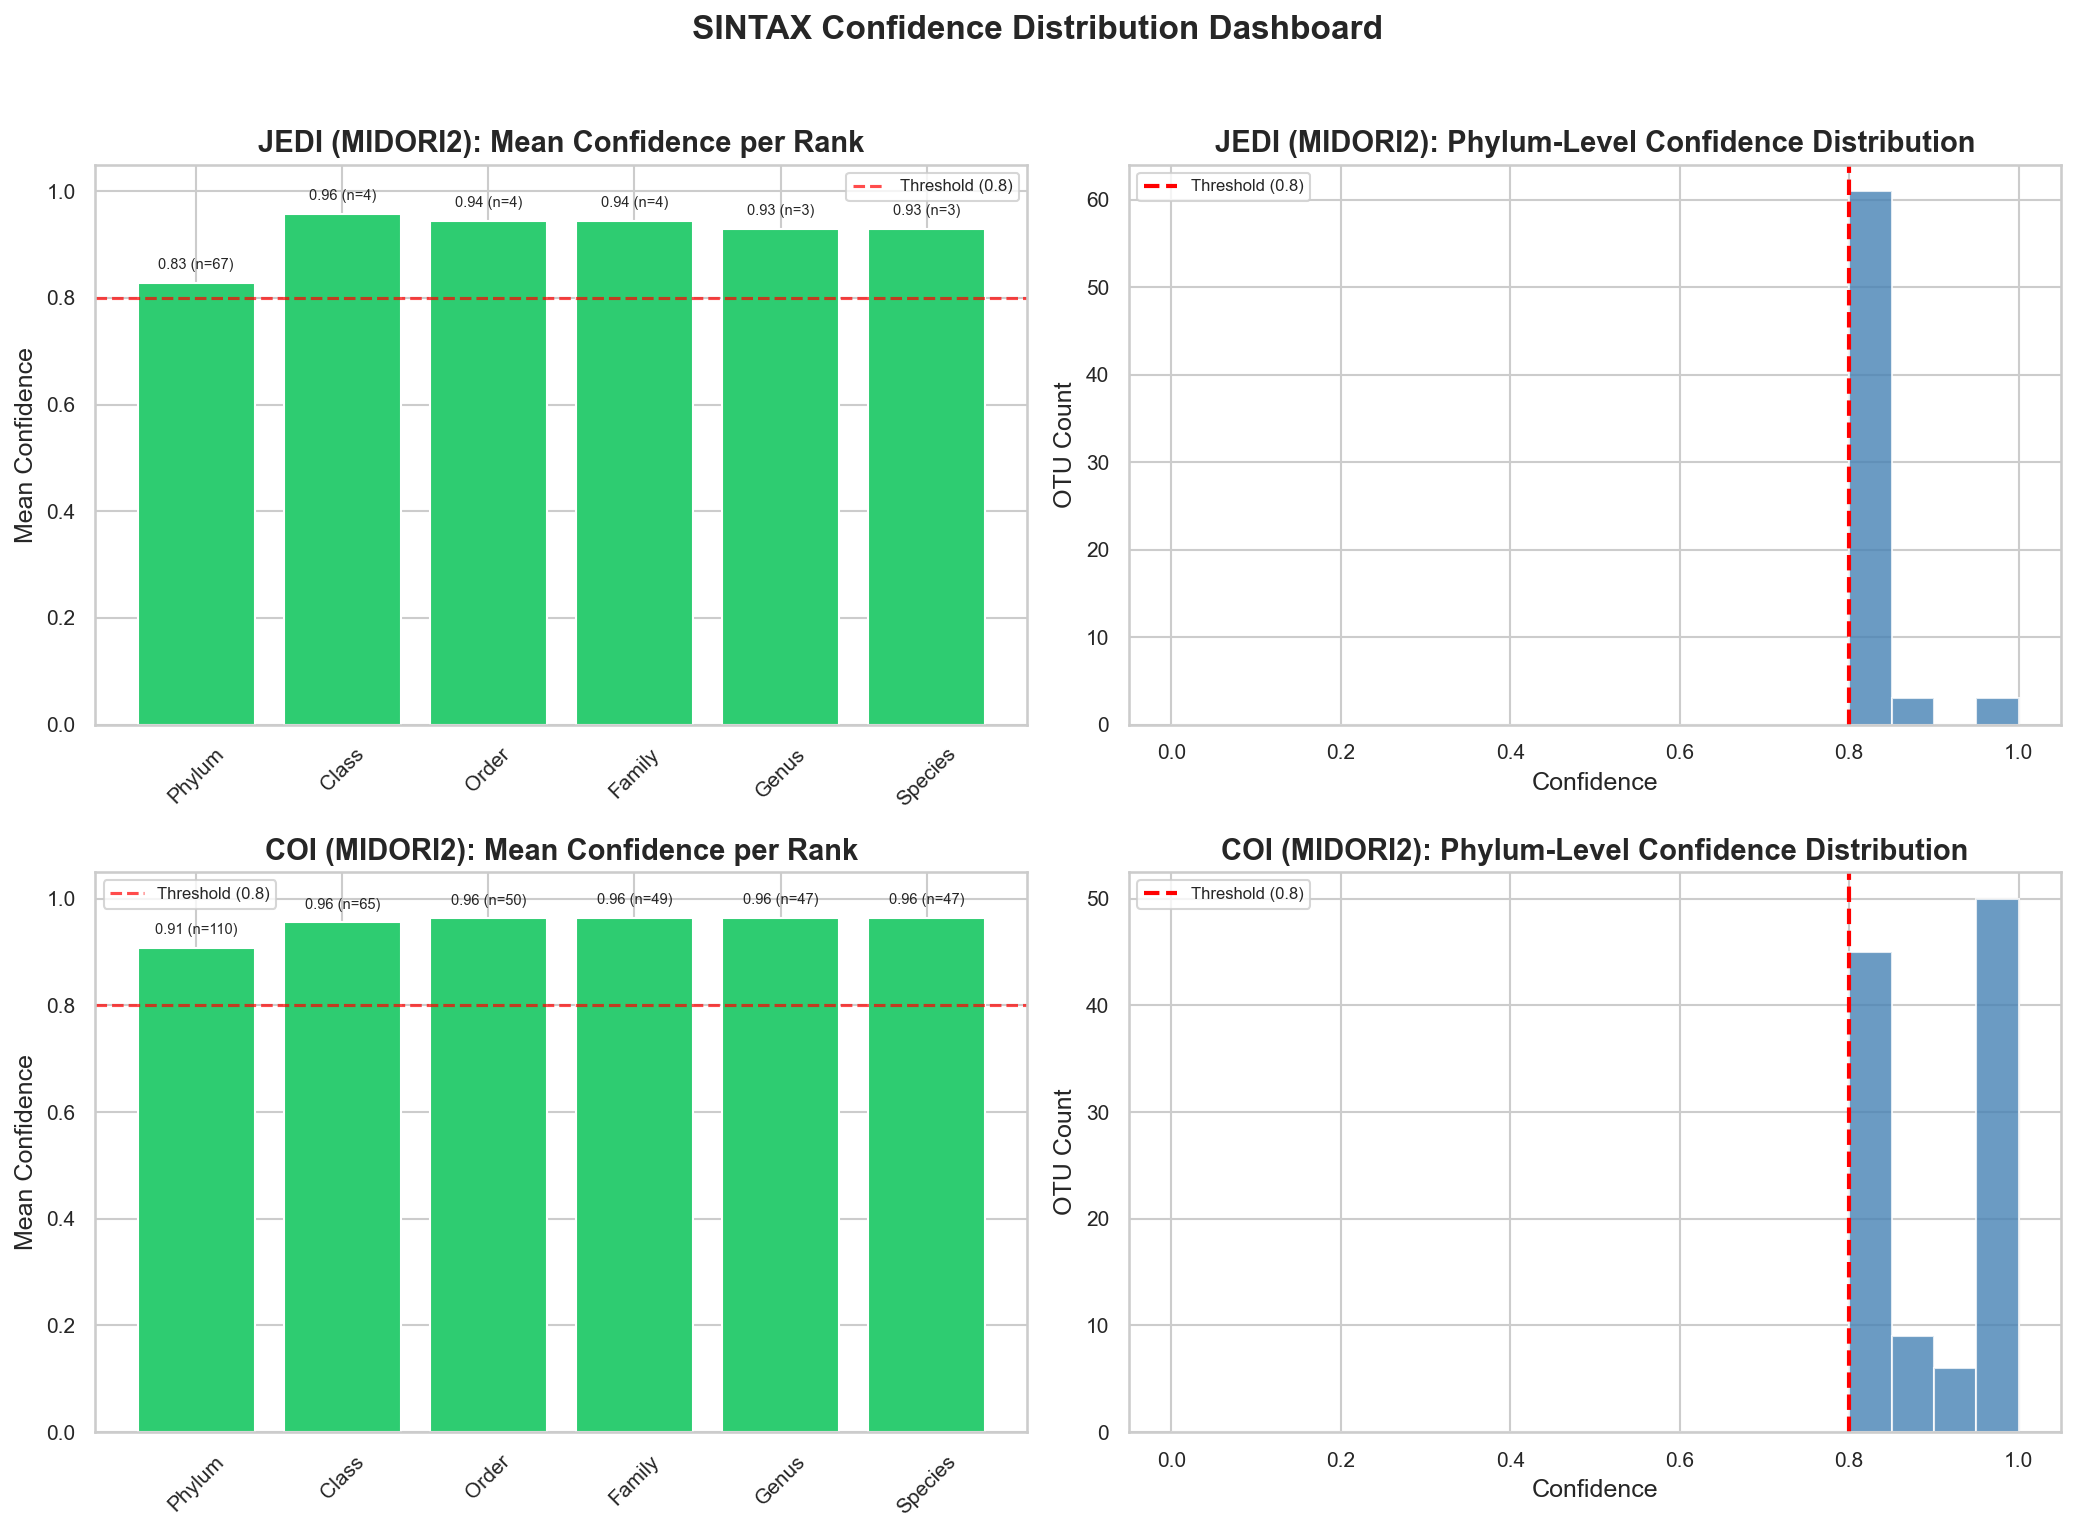

In [3]:
# === SINTAX Confidence Distribution Dashboard ===
ranks = ['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']

def plot_confidence_row(df, prefix, marker_label, axes):
    """Plot confidence metrics for one marker."""
    conf_cols = [f'{prefix}_{r}_Conf' for r in ranks]
    existing = [c for c in conf_cols if c in df.columns]
    if not existing:
        for ax in axes:
            ax.text(0.5, 0.5, 'No confidence columns found.\nRegenerate with:\nbash regenerate_taxonomy.sh',
                    ha='center', va='center', transform=ax.transAxes, fontsize=10, color='red')
            ax.set_title(marker_label)
        return

    means, counts = [], []
    for r in ranks:
        col = f'{prefix}_{r}_Conf'
        if col in df.columns:
            vals = pd.to_numeric(df[col], errors='coerce').dropna()
            means.append(vals.mean() if len(vals) > 0 else 0)
            counts.append(len(vals))
        else:
            means.append(0)
            counts.append(0)

    ax1 = axes[0]
    colors = ['#2ecc71' if m >= 0.8 else '#e74c3c' for m in means]
    bars = ax1.bar(ranks, means, color=colors, edgecolor='white')
    ax1.axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='Threshold (0.8)')
    ax1.set_ylim(0, 1.05)
    ax1.set_ylabel('Mean Confidence')
    ax1.set_title(f'{marker_label}: Mean Confidence per Rank', fontweight='bold')
    ax1.legend(fontsize=8)
    ax1.tick_params(axis='x', rotation=45)
    for bar, m, n in zip(bars, means, counts):
        if m > 0:
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{m:.2f} (n={n})', ha='center', va='bottom', fontsize=7)

    hist_rank = 'Genus' if prefix == 'SILVA' else 'Phylum'
    hist_col = f'{prefix}_{hist_rank}_Conf'
    ax2 = axes[1]
    if hist_col in df.columns:
        vals = pd.to_numeric(df[hist_col], errors='coerce').dropna()
        if len(vals) > 0:
            ax2.hist(vals, bins=20, range=(0, 1), color='steelblue', edgecolor='white', alpha=0.8)
            ax2.axvline(x=0.8, color='red', linestyle='--', linewidth=2, label='Threshold (0.8)')
            ax2.set_xlabel('Confidence')
            ax2.set_ylabel('OTU Count')
            ax2.set_title(f'{marker_label}: {hist_rank}-Level Confidence Distribution', fontweight='bold')
            ax2.legend(fontsize=8)
        else:
            ax2.text(0.5, 0.5, f'No {hist_rank} confidence values',
                    ha='center', va='center', transform=ax2.transAxes)
            ax2.set_title(f'{marker_label}: {hist_rank}-Level Confidence', fontweight='bold')
    else:
        ax2.text(0.5, 0.5, f'Column {hist_col} not found',
                ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title(f'{marker_label}: {hist_rank}-Level Confidence', fontweight='bold')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SINTAX Confidence Distribution Dashboard', fontsize=16, fontweight='bold', y=1.02)

plot_confidence_row(df_jedi_raw, prefix_jedi, f'JEDI ({prefix_jedi})', axes[0])
plot_confidence_row(df_coi_raw, prefix_coi, f'COI ({prefix_coi})', axes[1])

plt.tight_layout()
plt.show()

## Raw Read Length Distributions (Pre-Clustering)
Number of reads at each sequence length, aggregated across all barcodes for each marker. This reveals the actual abundance of reads by length before OTU clustering, highlighting primer dimers, truncated reads, or length biases in the sequencing run.

✓ JEDI: 29,852 reads, median=474bp, range=250-500bp
✓ COI: 79,093 reads, median=544bp, range=501-900bp


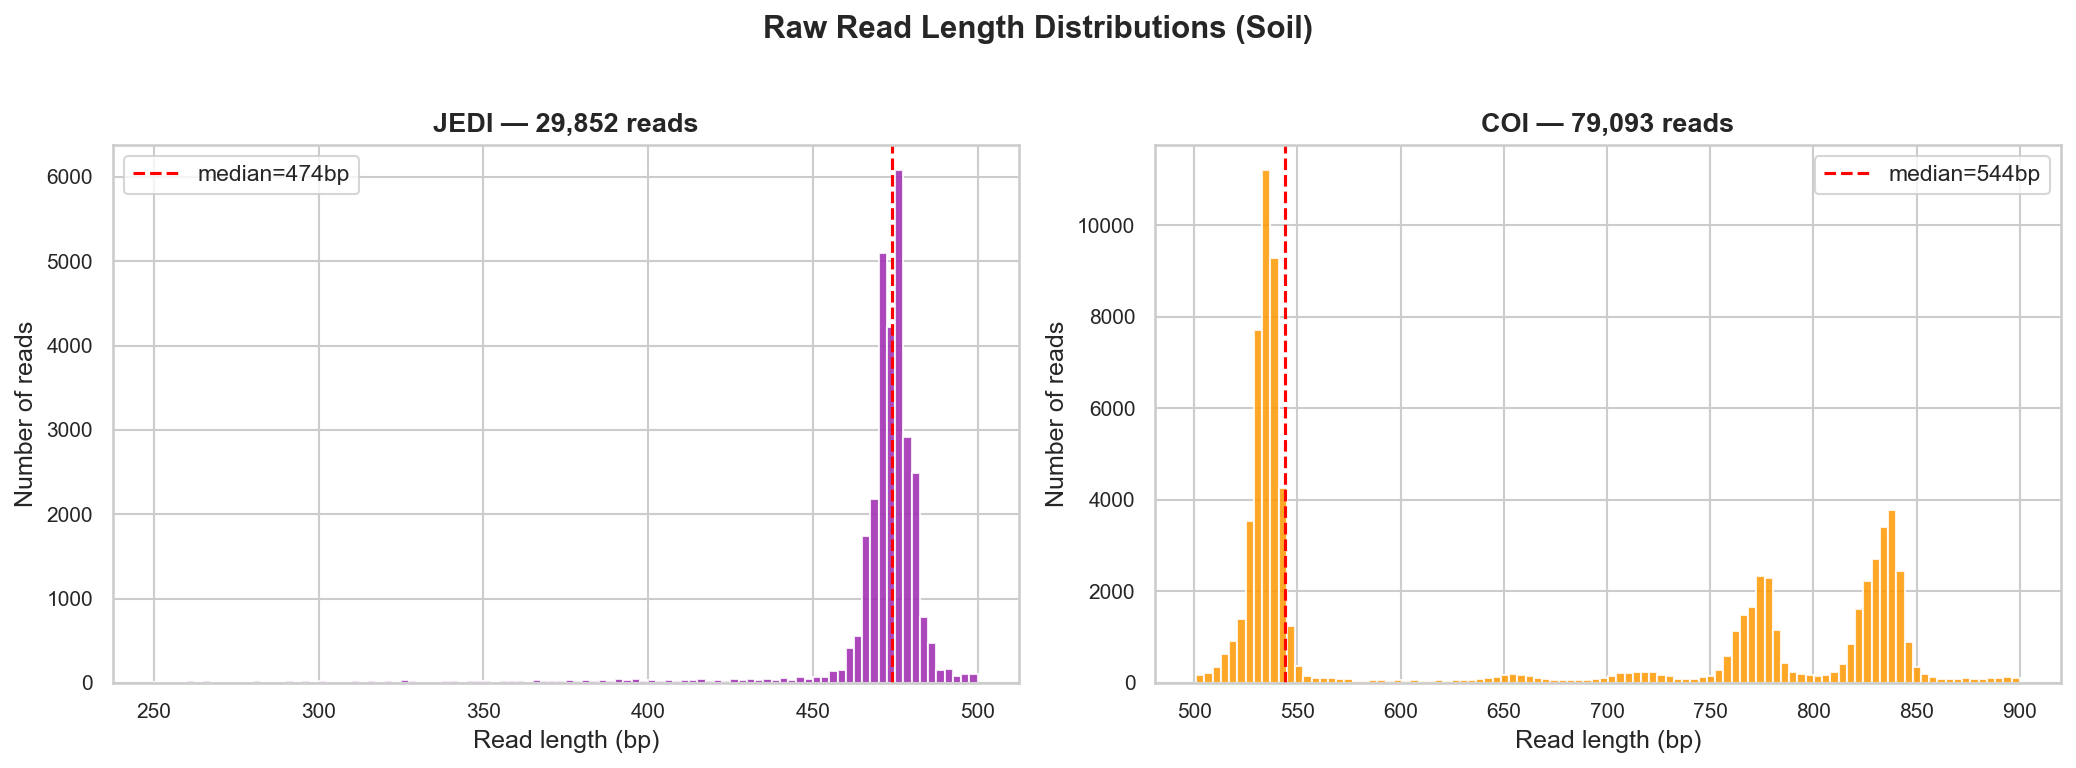

In [4]:
import gzip

# Collect raw read lengths per marker across all barcodes
barcode_dirs = sorted(BASE.glob("barcode*"))
marker_lengths = {"JEDI": [], "COI": []}
marker_colors_raw = {"JEDI": "#9C27B0", "COI": "#FF9800"}

for bd in barcode_dirs:
    for marker in marker_lengths:
        fq = bd / f"filtered_reads_{marker}.fastq.gz"
        if fq.exists():
            with gzip.open(str(fq), 'rt') as f:
                for i, line in enumerate(f):
                    if i % 4 == 1:  # sequence line
                        marker_lengths[marker].append(len(line.strip()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (marker, lengths) in enumerate(marker_lengths.items()):
    ax = axes[i]
    if lengths:
        ax.hist(lengths, bins=100, color=marker_colors_raw[marker], edgecolor="white", alpha=0.85)
        ax.axvline(np.median(lengths), color="red", ls="--", lw=1.5,
                   label=f"median={np.median(lengths):.0f}bp")
        ax.set_title(f"{marker} — {len(lengths):,} reads", fontsize=13, fontweight="bold")
        ax.set_xlabel("Read length (bp)")
        ax.set_ylabel("Number of reads")
        ax.legend()
        print(f"✓ {marker}: {len(lengths):,} reads, median={np.median(lengths):.0f}bp, "
              f"range={min(lengths)}-{max(lengths)}bp")
    else:
        ax.text(0.5, 0.5, f"{marker}\nNo reads found", ha='center', va='center', transform=ax.transAxes)

plt.suptitle("Raw Read Length Distributions (Soil)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Consensus OTU Sequence Length Distributions
Length distributions of consensus OTU sequences for each marker. Useful for identifying primer dimers, truncated reads, or off-target amplification.

✓ JEDI: 12103 OTUs, median=474bp, range=300-503bp
✓ COI: 29922 OTUs, median=539bp, range=500-907bp


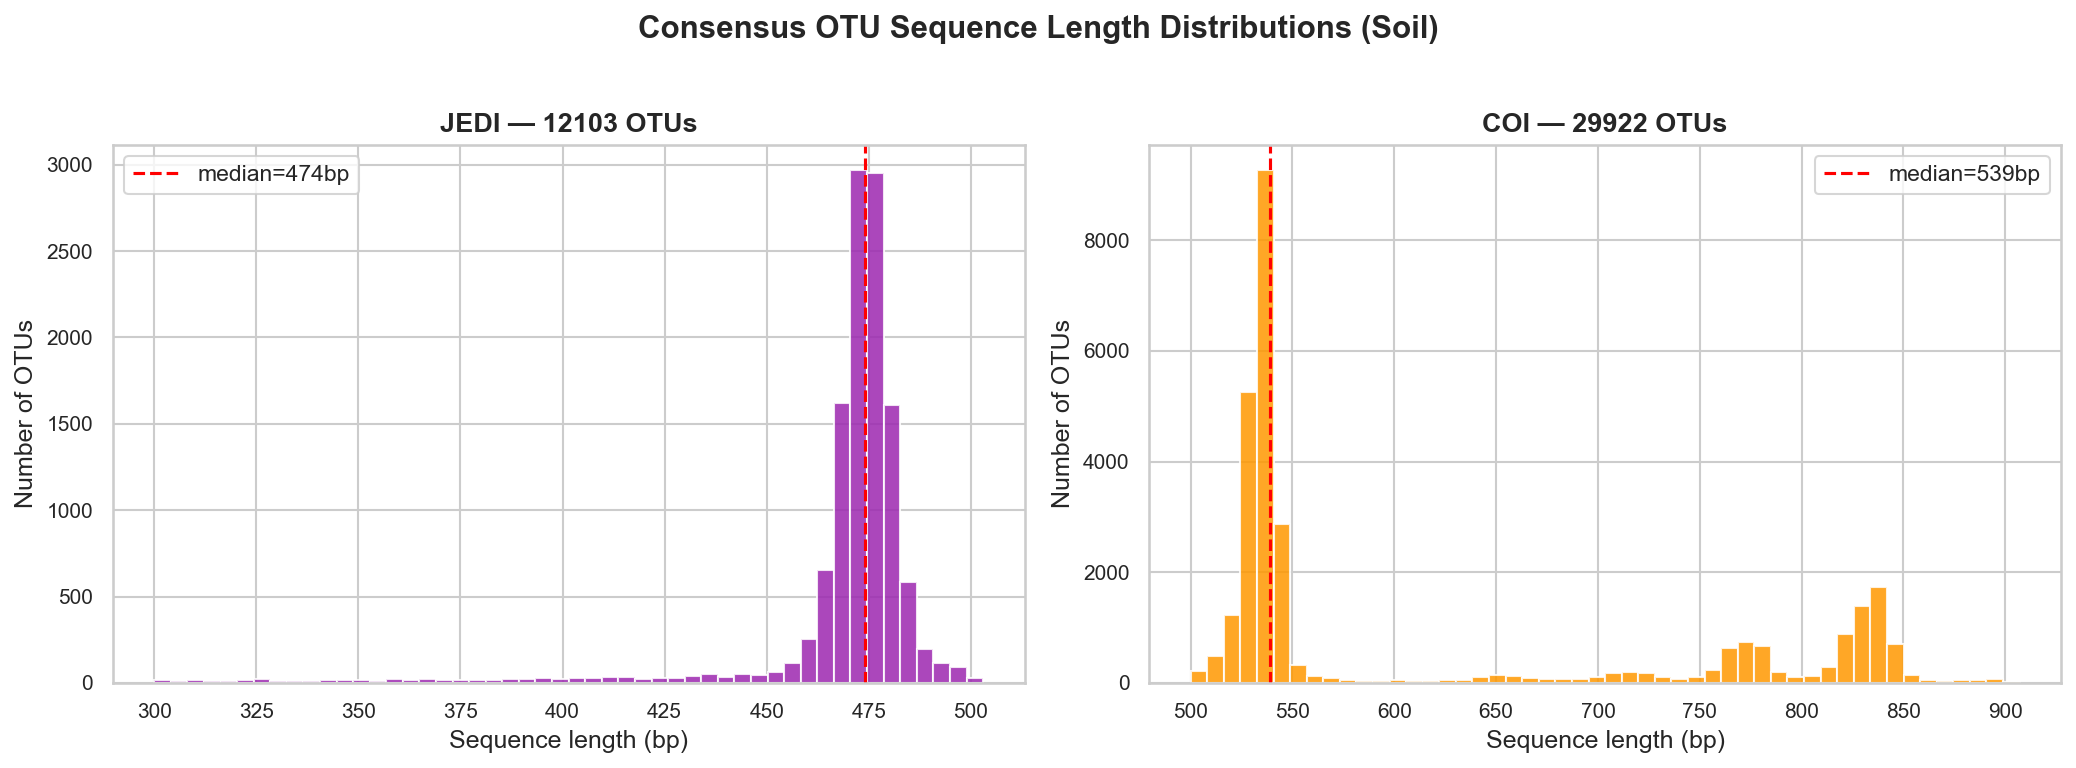

In [5]:
# Parse consensus FASTA files and plot sequence length distributions
fasta_files = {
    "JEDI": BASE / "temp_clustering/consensus_JEDI_clean.fasta",
    "COI":  BASE / "temp_clustering/consensus_COI_clean.fasta",
}
marker_colors = {"JEDI": "#9C27B0", "COI": "#FF9800"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (marker, path) in enumerate(fasta_files.items()):
    ax = axes[i]
    if path.exists():
        lengths = [len(rec.seq) for rec in SeqIO.parse(str(path), "fasta")]
        ax.hist(lengths, bins=50, color=marker_colors[marker], edgecolor="white", alpha=0.85)
        ax.axvline(np.median(lengths), color="red", ls="--", lw=1.5,
                   label=f"median={np.median(lengths):.0f}bp")
        ax.set_title(f"{marker} — {len(lengths)} OTUs", fontsize=13, fontweight="bold")
        ax.set_xlabel("Sequence length (bp)")
        ax.set_ylabel("Number of OTUs")
        ax.legend()
        print(f"✓ {marker}: {len(lengths)} OTUs, median={np.median(lengths):.0f}bp, "
              f"range={min(lengths)}-{max(lengths)}bp")
    else:
        ax.text(0.5, 0.5, f"{marker}\nFASTA not found", ha='center', va='center', transform=ax.transAxes)

plt.suptitle("Consensus OTU Sequence Length Distributions (Soil)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
# Part A: JEDI Marker Biodiversity Analysis
*Objective: To characterize the soil invertebrate community structure using the JEDI marker (~460 bp COI), optimized for arthropod detection.*

## A.1a Broad Taxonomic Structure
This stacked bar chart visualizes the relative abundance of Phyla across all soil samples.
* **Expected Result:** We expect high abundances of **Arthropoda** (insects, collembolans, mites) and possibly **Annelida** (earthworms) and **Nematoda**.
* **Soil Signal:** Unlike water samples where Ciliophora dominates, soil samples should show a strong terrestrial invertebrate signal.

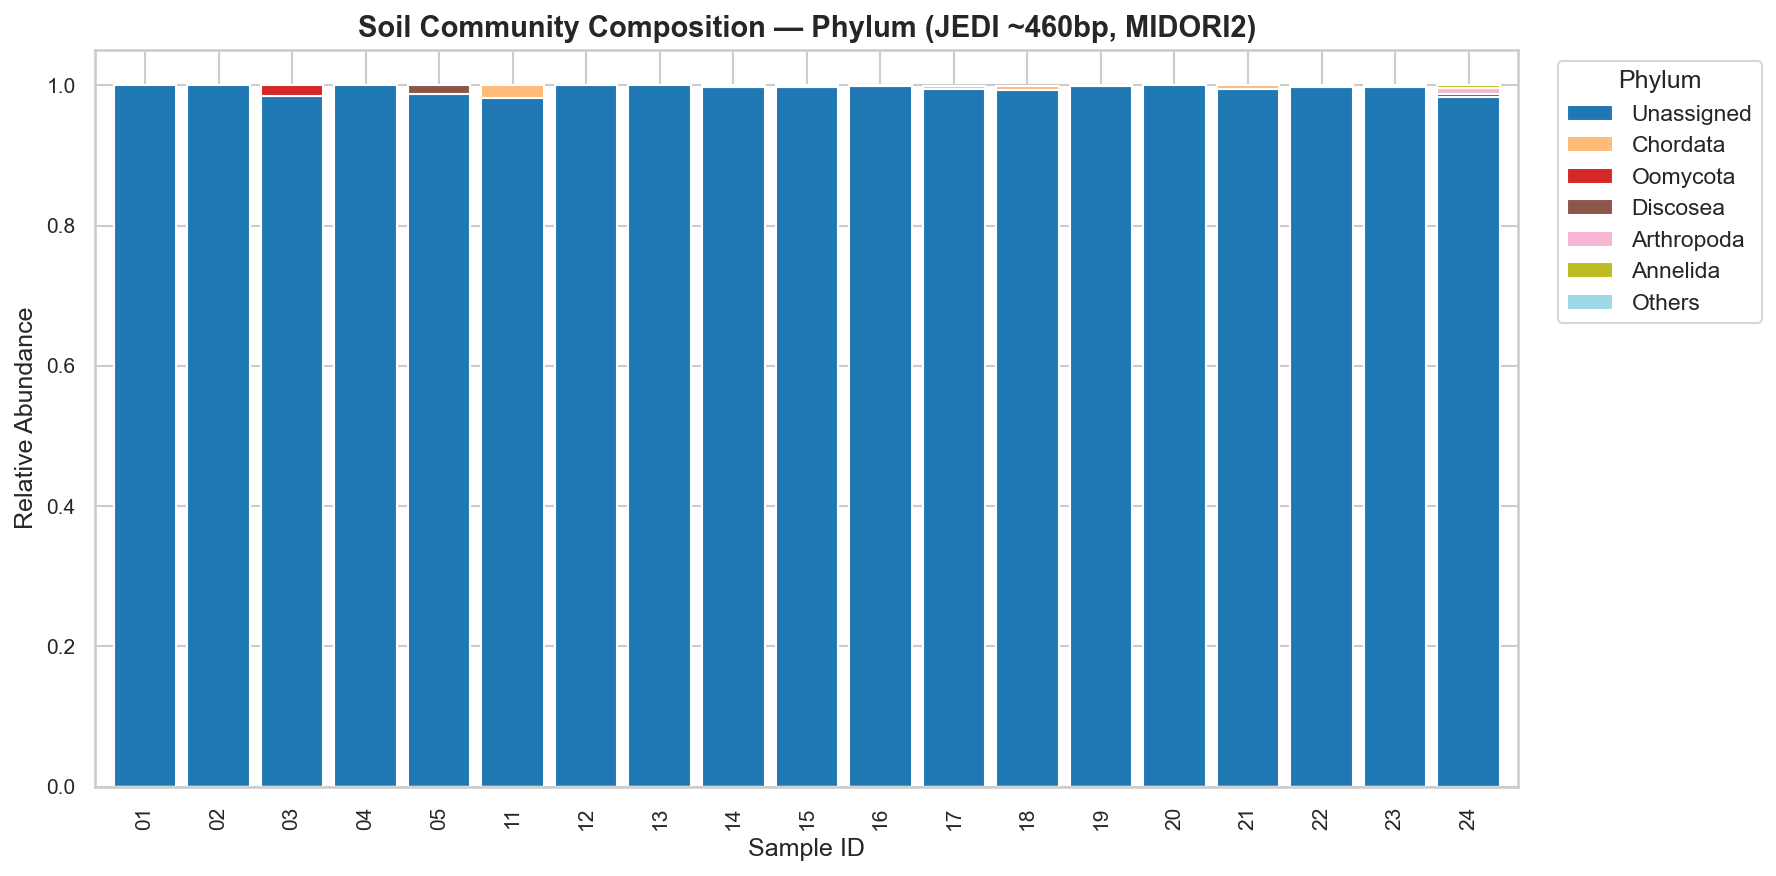

In [6]:
# JEDI Phylum-level plot (data already loaded above)
df_jedi = df_jedi_raw.copy()
df_jedi = clean_midori_taxonomy(df_jedi, prefix_jedi)
sample_cols_jedi = [c for c in df_jedi.columns if c.startswith('Sample_') and 'unclassified' not in c]
phylum_col_jedi = f'{prefix_jedi}_Phylum'

df_jedi[phylum_col_jedi] = df_jedi[phylum_col_jedi].fillna('Unassigned')
phylum_jedi = df_jedi.groupby(phylum_col_jedi)[sample_cols_jedi].sum()

# Sort and Group "Others"
phylum_jedi['Total'] = phylum_jedi.sum(axis=1)
phylum_jedi = phylum_jedi.sort_values('Total', ascending=False)
top_phyla = phylum_jedi.head(10).index

plot_data = phylum_jedi.loc[top_phyla].drop(columns='Total')
others = phylum_jedi.loc[~phylum_jedi.index.isin(top_phyla)].drop(columns='Total').sum()
plot_data.loc['Others'] = others

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
plot_data.columns = clean_sample_names(plot_data.columns)
plot_data.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, cmap='tab20')

ax.set_title(f'Soil Community Composition — Phylum (JEDI ~460bp, {prefix_jedi})', fontweight='bold')
ax.set_xlabel('Sample ID')
ax.set_ylabel('Relative Abundance')
ax.legend(title='Phylum', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## A.1b Class-Level Breakdown (JEDI)
**Objective:** To see which specific biological Classes dominate within the broad Phyla.

**Visual Analysis:**
1. **Insecta:** Expected to dominate as the primary soil arthropod class.
2. **Collembola:** Springtails are key soil decomposers — their presence validates the soil sampling quality.
3. **Arachnida:** Mites and spiders indicate a well-functioning soil food web.

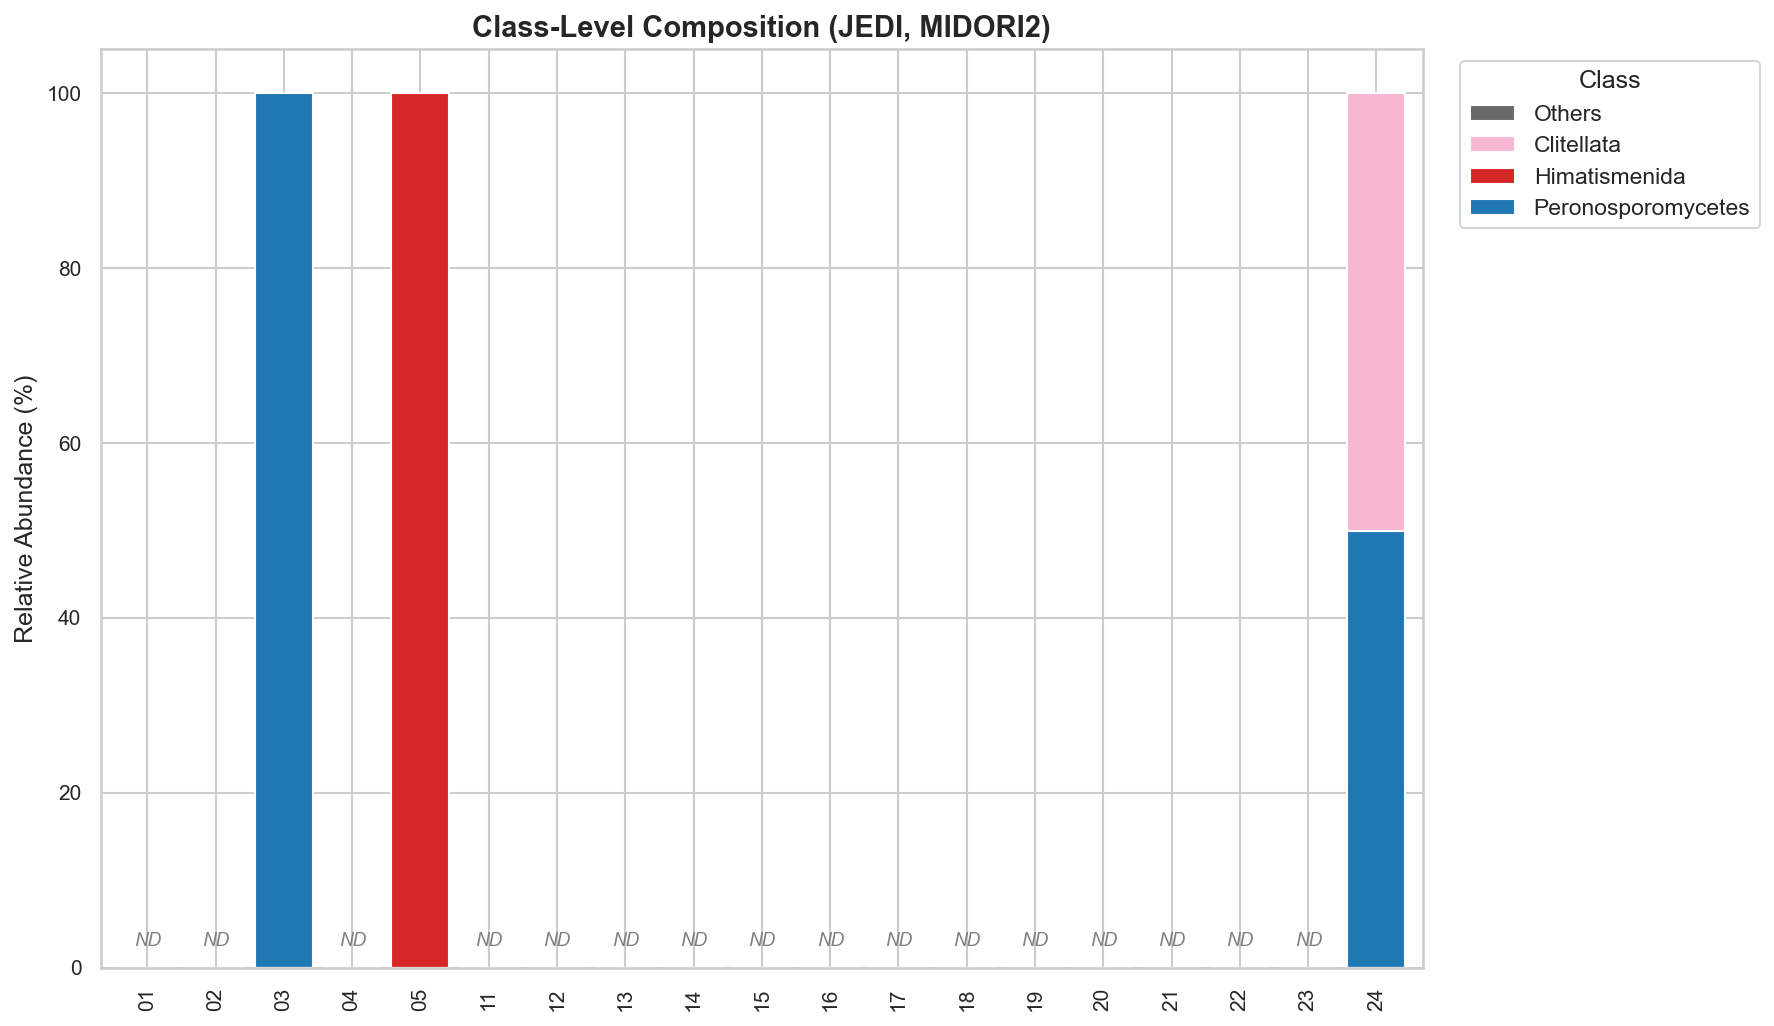

In [7]:
# Group by Class (JEDI)
class_col_jedi = f'{prefix_jedi}_Class'
df_jedi[class_col_jedi] = df_jedi[class_col_jedi].fillna('Unassigned')
class_jedi = df_jedi.groupby(class_col_jedi)[sample_cols_jedi].sum()
class_jedi = class_jedi.drop('Unassigned', errors='ignore')

# Sort and Top 15
class_jedi['Total'] = class_jedi.sum(axis=1)
class_jedi = class_jedi.sort_values('Total', ascending=False)
top_classes = class_jedi.head(15).index

# Prepare Data
plot_cls = class_jedi.loc[top_classes].drop(columns='Total')
others_cls = class_jedi.loc[~class_jedi.index.isin(top_classes)].drop(columns='Total').sum()
plot_cls.loc['Others'] = others_cls

# Custom color logic
num_colors = len(plot_cls)
colors = cm.tab20(np.linspace(0, 1, num_colors))
custom_colors = []
for i, cls_name in enumerate(plot_cls.index):
    if cls_name == 'Unassigned':
        custom_colors.append('#D3D3D3')
    elif cls_name == 'Others':
        custom_colors.append('#696969')
    else:
        custom_colors.append(colors[i])

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
plot_cls.columns = clean_sample_names(plot_cls.columns)
plot_cls = plot_cls.div(plot_cls.sum(axis=0), axis=1) * 100  # normalize to %
plot_cls = plot_cls.fillna(0)
plot_cls.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, color=custom_colors)

ax.set_title(f'Class-Level Composition (JEDI, {prefix_jedi})', fontweight='bold')
ax.set_ylabel('Relative Abundance (%)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), bbox_to_anchor=(1.02, 1), loc='upper left', title='Class')

# Mark samples with no assigned taxa
for _idx, _sample in enumerate(plot_cls.columns):
    if plot_cls[_sample].sum() == 0:
        ax.text(_idx, 2, 'ND', ha='center', va='bottom',
                fontsize=9, color='gray', fontstyle='italic')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## A.2 Order-Level Breakdown (JEDI)
Order-level community composition for the JEDI marker.

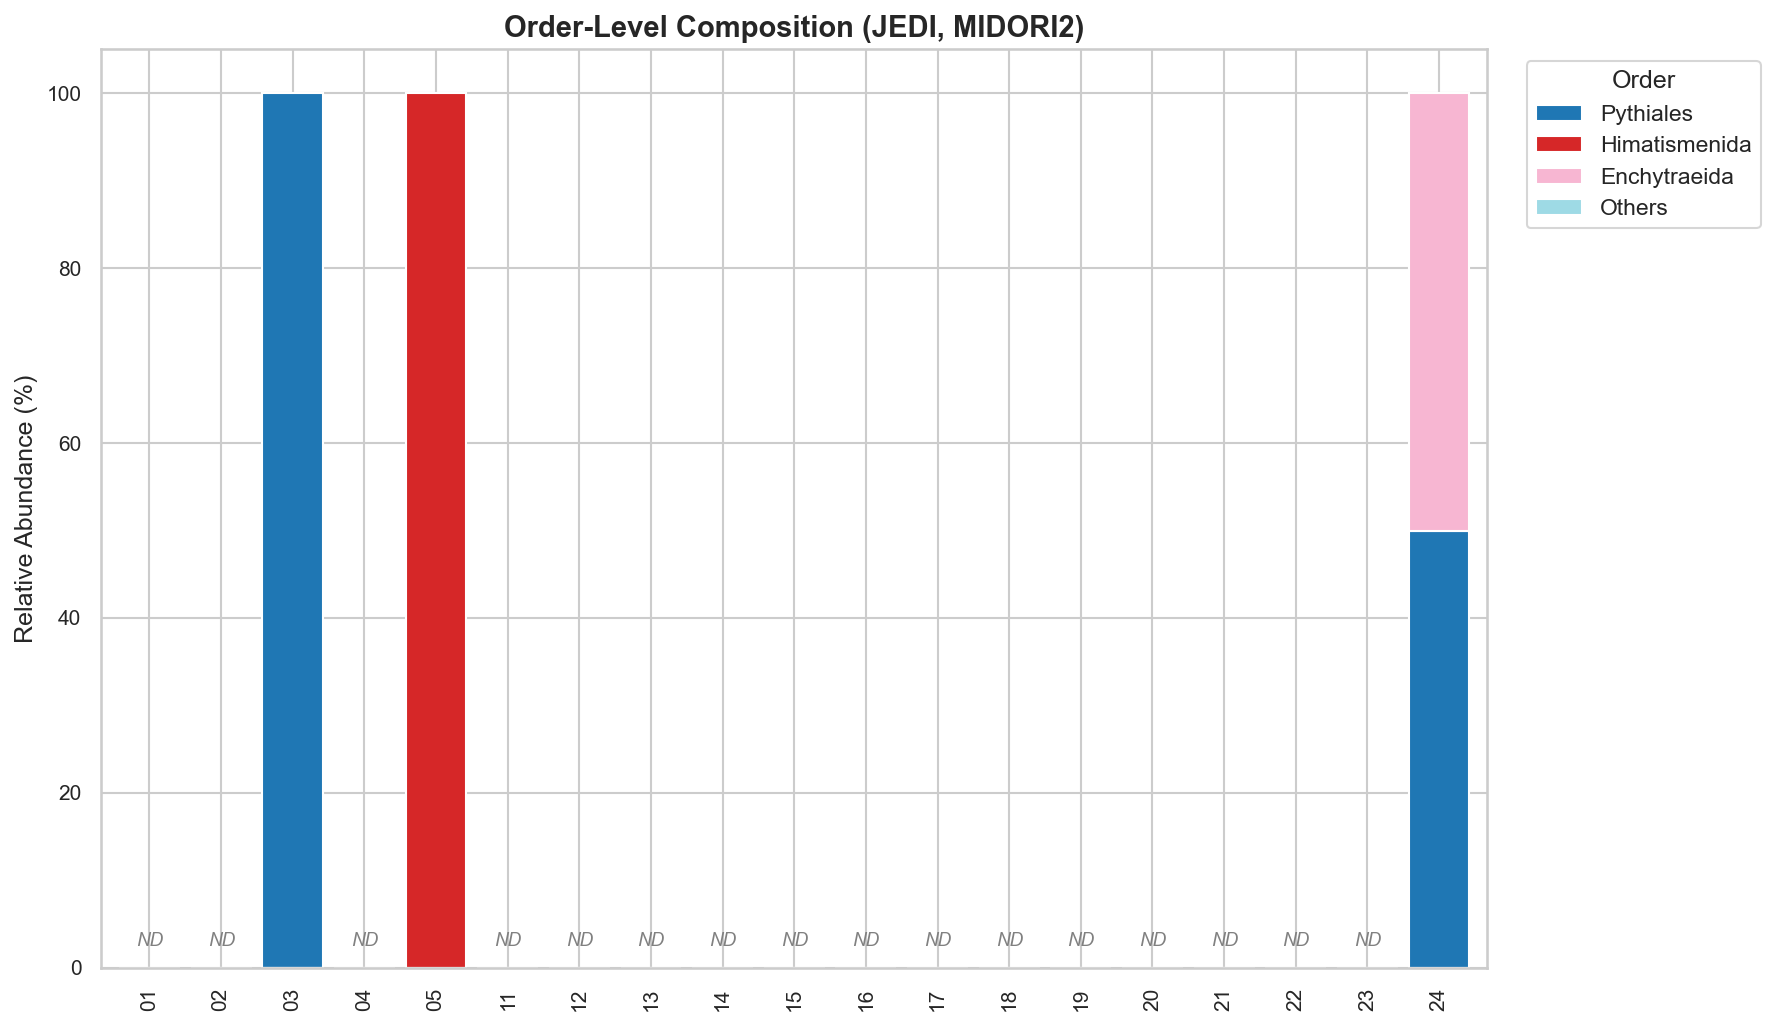

In [8]:
order_col_jedi = f'{prefix_jedi}_Order'
df_jedi[order_col_jedi] = df_jedi[order_col_jedi].fillna('Unassigned')
order_jedi = df_jedi.groupby(order_col_jedi)[sample_cols_jedi].sum()
order_jedi = order_jedi.drop('Unassigned', errors='ignore')

order_jedi['Total'] = order_jedi.sum(axis=1)
order_jedi = order_jedi.sort_values('Total', ascending=False)
top_orders = order_jedi.head(15).index

plot_ord = order_jedi.loc[top_orders].drop(columns='Total')
others_ord = order_jedi.loc[~order_jedi.index.isin(top_orders)].drop(columns='Total').sum()
plot_ord.loc['Others'] = others_ord

fig, ax = plt.subplots(figsize=(12, 7))
plot_ord.columns = clean_sample_names(plot_ord.columns)
plot_ord = plot_ord.div(plot_ord.sum(axis=0), axis=1) * 100  # normalize to %
plot_ord = plot_ord.fillna(0)
plot_ord.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, cmap='tab20')

ax.set_title(f'Order-Level Composition (JEDI, {prefix_jedi})', fontweight='bold')
ax.set_ylabel('Relative Abundance (%)')
ax.legend(title='Order', bbox_to_anchor=(1.02, 1), loc='upper left')

for _idx, _sample in enumerate(plot_ord.columns):
    if plot_ord[_sample].sum() == 0:
        ax.text(_idx, 2, 'ND', ha='center', va='bottom',
                fontsize=9, color='gray', fontstyle='italic')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## A.3 Genus-Level Top 20 (JEDI)
Top genera detected by the JEDI marker with confidence annotations.

C:\Users\ilias\AppData\Local\Temp\ipykernel_26612\896560846.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genera['Total'], y=top_genera.index, palette='viridis', ax=ax)


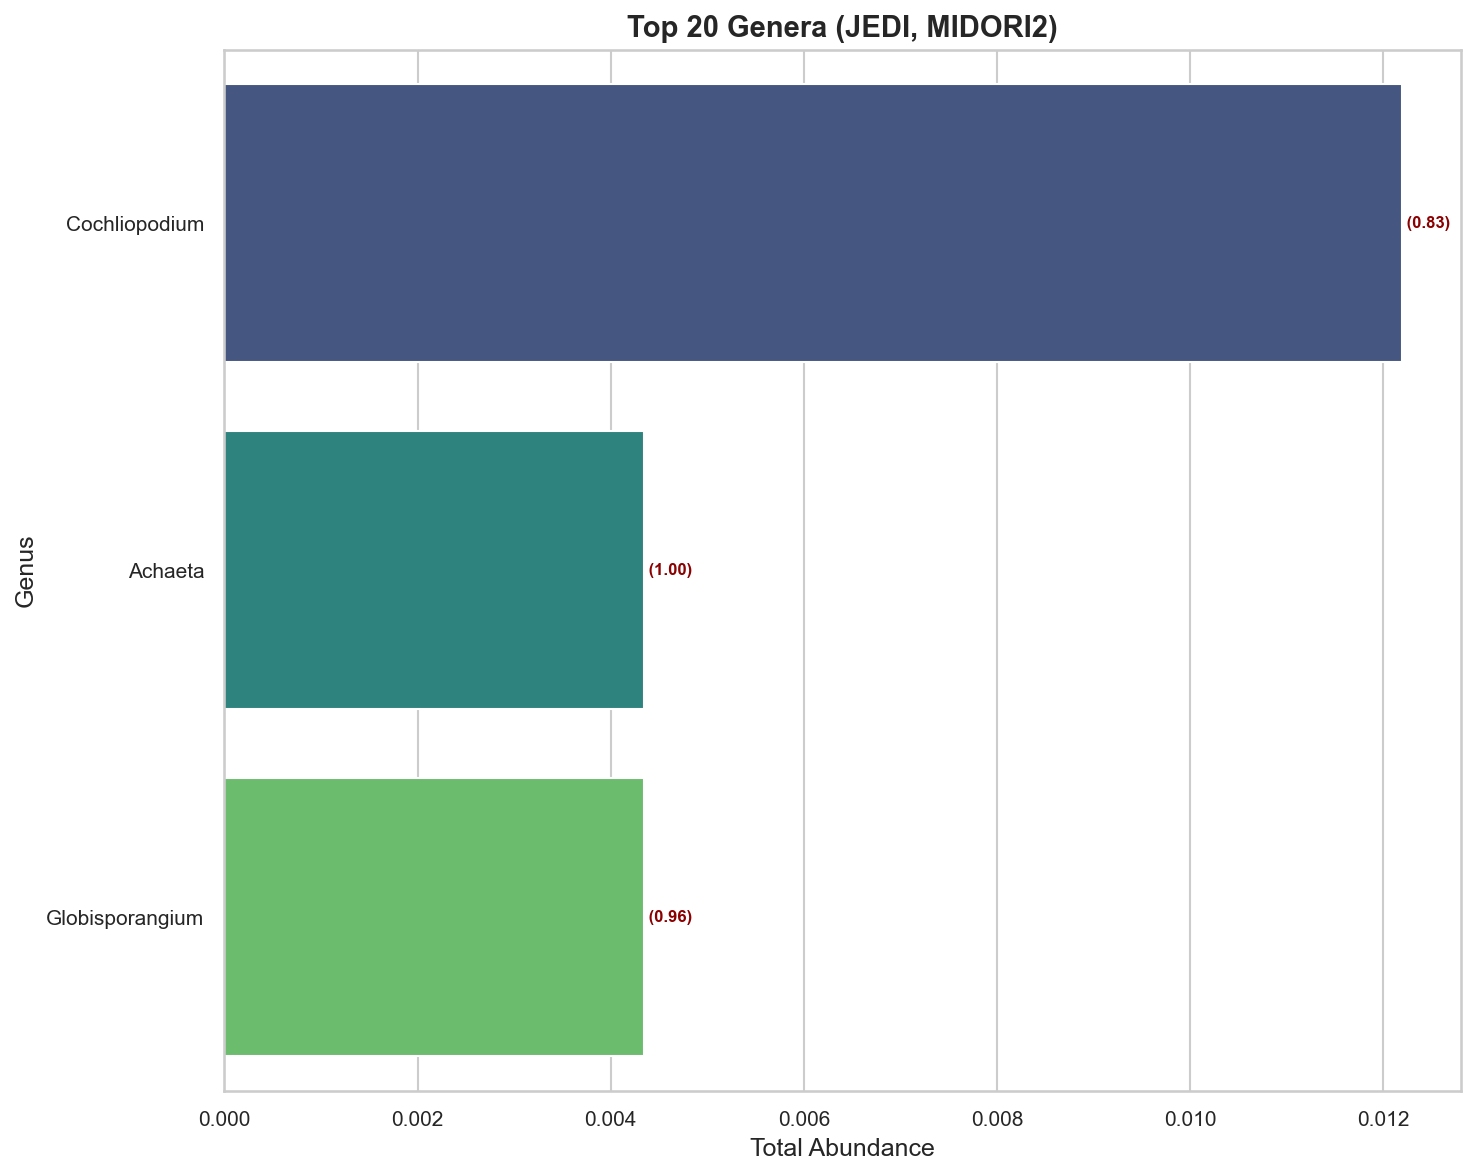

In [9]:
genus_col_jedi = f'{prefix_jedi}_Genus'
df_jedi[genus_col_jedi] = df_jedi[genus_col_jedi].fillna('Unassigned')
genus_jedi = df_jedi.groupby(genus_col_jedi)[sample_cols_jedi].sum()
genus_jedi = genus_jedi.drop('Unassigned', errors='ignore')
genus_jedi['Total'] = genus_jedi.sum(axis=1)
genus_jedi = genus_jedi.sort_values('Total', ascending=False)

top_genera = genus_jedi.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top_genera['Total'], y=top_genera.index, palette='viridis', ax=ax)
ax.set_title(f'Top 20 Genera (JEDI, {prefix_jedi})', fontweight='bold')
ax.set_xlabel('Total Abundance')
ax.set_ylabel('Genus')

_genus_conf_col = f'{prefix_jedi}_Genus_Conf'
if _genus_conf_col in df_jedi.columns:
    for _i, _genus_name in enumerate(top_genera.index):
        _mask = df_jedi[genus_col_jedi] == _genus_name
        _cvals = pd.to_numeric(df_jedi.loc[_mask, _genus_conf_col], errors='coerce').dropna()
        if len(_cvals) > 0:
            _mc = _cvals.mean()
            ax.text(top_genera['Total'].iloc[_i], _i, f' ({_mc:.2f})',
                    va='center', ha='left', fontsize=8, color='darkred', fontweight='bold')
plt.tight_layout()
plt.show()

### Top 20 Genera by Abundance — All Confidences (JEDI)
Same marker but showing ALL genus assignments regardless of confidence, ranked by abundance. Bars are color-coded by mean confidence level.

In [ ]:
# Top 20 Genera by ABUNDANCE (including low-confidence assignments)
genus_raw_col = f'{prefix_jedi}_Genus_Raw'
genus_raw_conf_col = f'{prefix_jedi}_Genus_Raw_Conf'

if genus_raw_col in df_jedi.columns:
    df_tmp = df_jedi.copy()
    df_tmp[genus_raw_col] = df_tmp[genus_raw_col].fillna('Unassigned')
    genus_abund = df_tmp.groupby(genus_raw_col)[sample_cols_jedi].sum()
    genus_abund = genus_abund.drop('Unassigned', errors='ignore')
    genus_abund['Total'] = genus_abund.sum(axis=1)
    genus_abund = genus_abund.sort_values('Total', ascending=False)
    top20 = genus_abund.head(20)

    # Compute mean confidence per genus (raw)
    raw_conf = {}
    for genus in top20.index:
        mask = df_tmp[genus_raw_col] == genus
        vals = pd.to_numeric(df_tmp.loc[mask, genus_raw_conf_col], errors='coerce').dropna()
        raw_conf[genus] = vals.mean() if len(vals) > 0 else None

    fig, ax = plt.subplots(figsize=(11, 8))
    colors = []
    for genus in top20.index:
        c = raw_conf.get(genus)
        if c is None:
            colors.append('#999999')
        elif c >= 0.8:
            colors.append('#2d8a4e')
        elif c >= 0.5:
            colors.append('#e6a817')
        else:
            colors.append('#c0392b')

    bars = ax.barh(range(len(top20)), top20['Total'].values[::-1], color=colors[::-1], height=0.7)
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20.index[::-1], fontsize=9)
    ax.set_xlabel('Total Abundance', fontsize=11)
    ax.set_title(f'Top 20 Genera by Abundance — All Confidences (JEDI, {prefix_jedi})',
                 fontweight='bold', fontsize=12)

    xmax = top20['Total'].max()
    for j, genus in enumerate(top20.index[::-1]):
        c = raw_conf.get(genus)
        if c is not None:
            color = '#2d8a4e' if c >= 0.8 else '#e6a817' if c >= 0.5 else '#c0392b'
            ax.text(top20.loc[genus, 'Total'] + xmax * 0.01, j,
                    f' {c:.2f}', va='center', fontsize=9, fontweight='bold', color=color)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2d8a4e', label='\u2265 0.80 (confident)'),
        Patch(facecolor='#e6a817', label='0.50 \u2013 0.79 (moderate)'),
        Patch(facecolor='#c0392b', label='< 0.50 (low confidence)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
              title='Mean confidence', title_fontsize=9, framealpha=0.9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print(f'Column {genus_raw_col} not found — re-run regenerate_taxonomy.sh to generate raw genus columns.')

## A.4 The "Unassigned" Reality Check (JEDI)
**Limitation:** A significant portion of reads may remain "Unassigned," especially at lower taxonomic levels.

**Why does this happen?**
1. **Database Gaps:** MIDORI2 lacks many soil invertebrate sequences, especially for local Swiss fauna.
2. **Strict Thresholds:** The 0.8 confidence threshold means uncertain assignments are marked "Unassigned" rather than guessed.
3. **Methodological Choice:** Accuracy over coverage — better to label a sequence as unknown than provide a false identification.

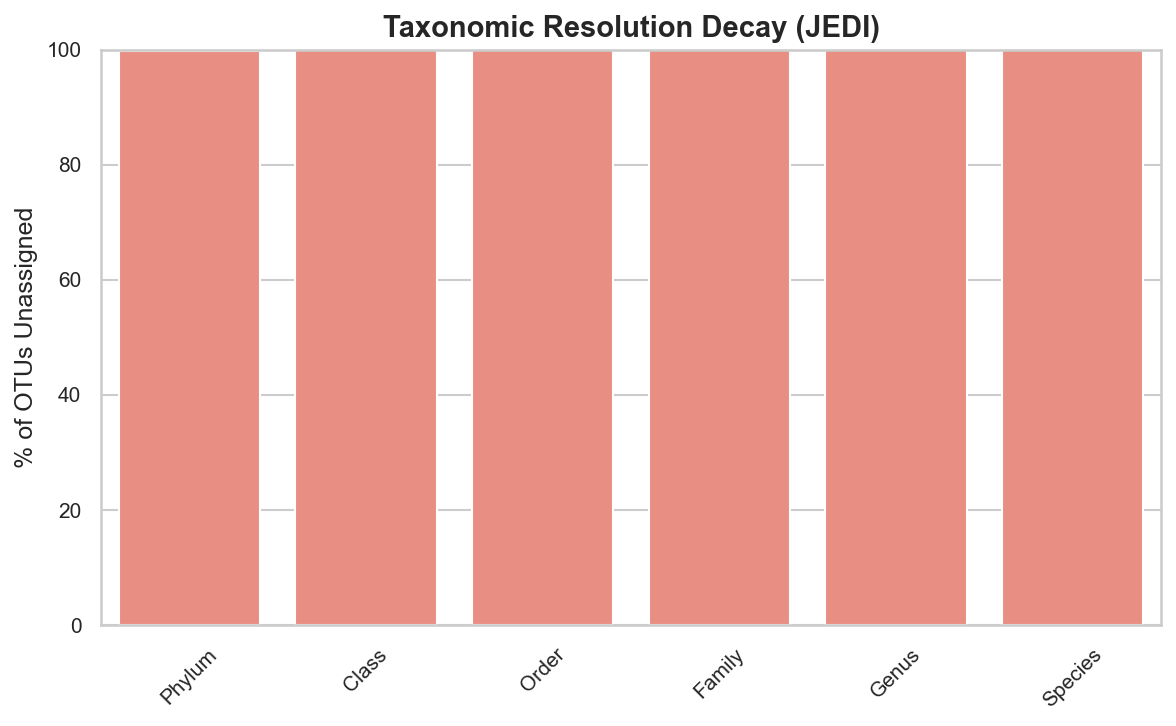

In [10]:
# Calculate % Unassigned at each level (JEDI)
ranks = ['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
levels_jedi = [f'{prefix_jedi}_{r}' for r in ranks]
unassigned_counts_jedi = []

for level in levels_jedi:
    n_unassigned = df_jedi[level].isin(['Unassigned', np.nan]).sum()
    pct = (n_unassigned / len(df_jedi)) * 100
    unassigned_counts_jedi.append(pct)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=ranks, y=unassigned_counts_jedi, color="salmon")
plt.title('Taxonomic Resolution Decay (JEDI)', fontweight='bold')
plt.ylabel('% of OTUs Unassigned')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

---
# Part B: COI Marker Biodiversity Analysis (Standard Folmer ~658 bp)
*Objective: To characterize the soil community using the standard COI marker and compare its performance with the JEDI marker in a soil matrix.*

**Technical Context:** The standard Folmer COI primers (~658 bp) target a broader range of metazoans but require longer intact DNA fragments. In soil, where DNA degradation is common, this marker may underperform compared to JEDI.

## B.1a Broad Taxonomic Structure (COI)
This stacked bar chart visualizes the relative abundance of Phyla across all soil samples using the standard COI marker.
* **Expected Result:** Similar taxa to JEDI but potentially with fewer reads due to DNA degradation favoring shorter fragments.
* **Comparison:** Differences between JEDI and COI compositions may reveal primer bias or DNA quality effects.

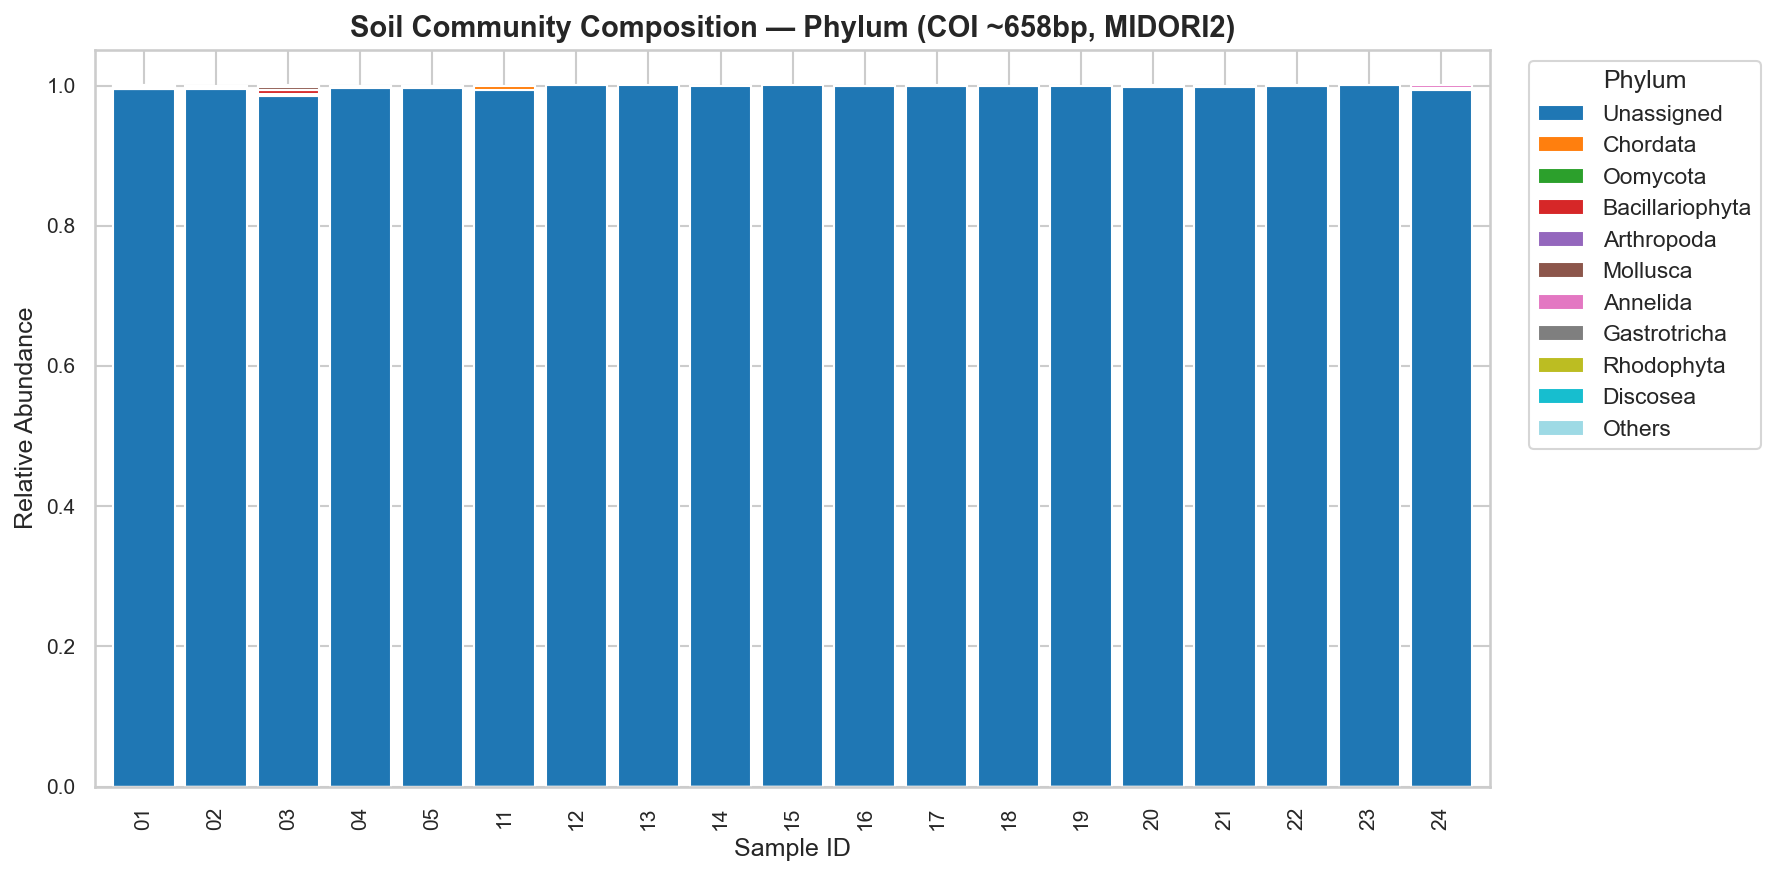

In [11]:
# COI Phylum-level plot (data already loaded above)
df_coi = df_coi_raw.copy()
df_coi = clean_midori_taxonomy(df_coi, prefix_coi)
sample_cols_coi = [c for c in df_coi.columns if c.startswith('Sample_') and 'unclassified' not in c]
phylum_col_coi = f'{prefix_coi}_Phylum'

df_coi[phylum_col_coi] = df_coi[phylum_col_coi].fillna('Unassigned')
phylum_coi = df_coi.groupby(phylum_col_coi)[sample_cols_coi].sum()

# Sort and Group "Others"
phylum_coi['Total'] = phylum_coi.sum(axis=1)
phylum_coi = phylum_coi.sort_values('Total', ascending=False)
top_phyla_coi = phylum_coi.head(10).index

plot_data_coi = phylum_coi.loc[top_phyla_coi].drop(columns='Total')
others_coi = phylum_coi.loc[~phylum_coi.index.isin(top_phyla_coi)].drop(columns='Total').sum()
plot_data_coi.loc['Others'] = others_coi

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
plot_data_coi.columns = clean_sample_names(plot_data_coi.columns)
plot_data_coi.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, cmap='tab20')

ax.set_title(f'Soil Community Composition — Phylum (COI ~658bp, {prefix_coi})', fontweight='bold')
ax.set_xlabel('Sample ID')
ax.set_ylabel('Relative Abundance')
ax.legend(title='Phylum', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## B.1b Class-Level Breakdown (COI)
**Objective:** To see which specific biological Classes dominate within the broad Phyla for the standard COI marker.

**Visual Analysis:**
1. **Comparison with JEDI:** Do the same Classes appear, or does the longer COI fragment capture different taxa?
2. **Actinopteri / Insecta:** These are the most recognizable animal classes for easy interpretation.
3. **Sordariomycetes (Fungi):** Watch for this fungal class which may dominate due to off-target amplification.

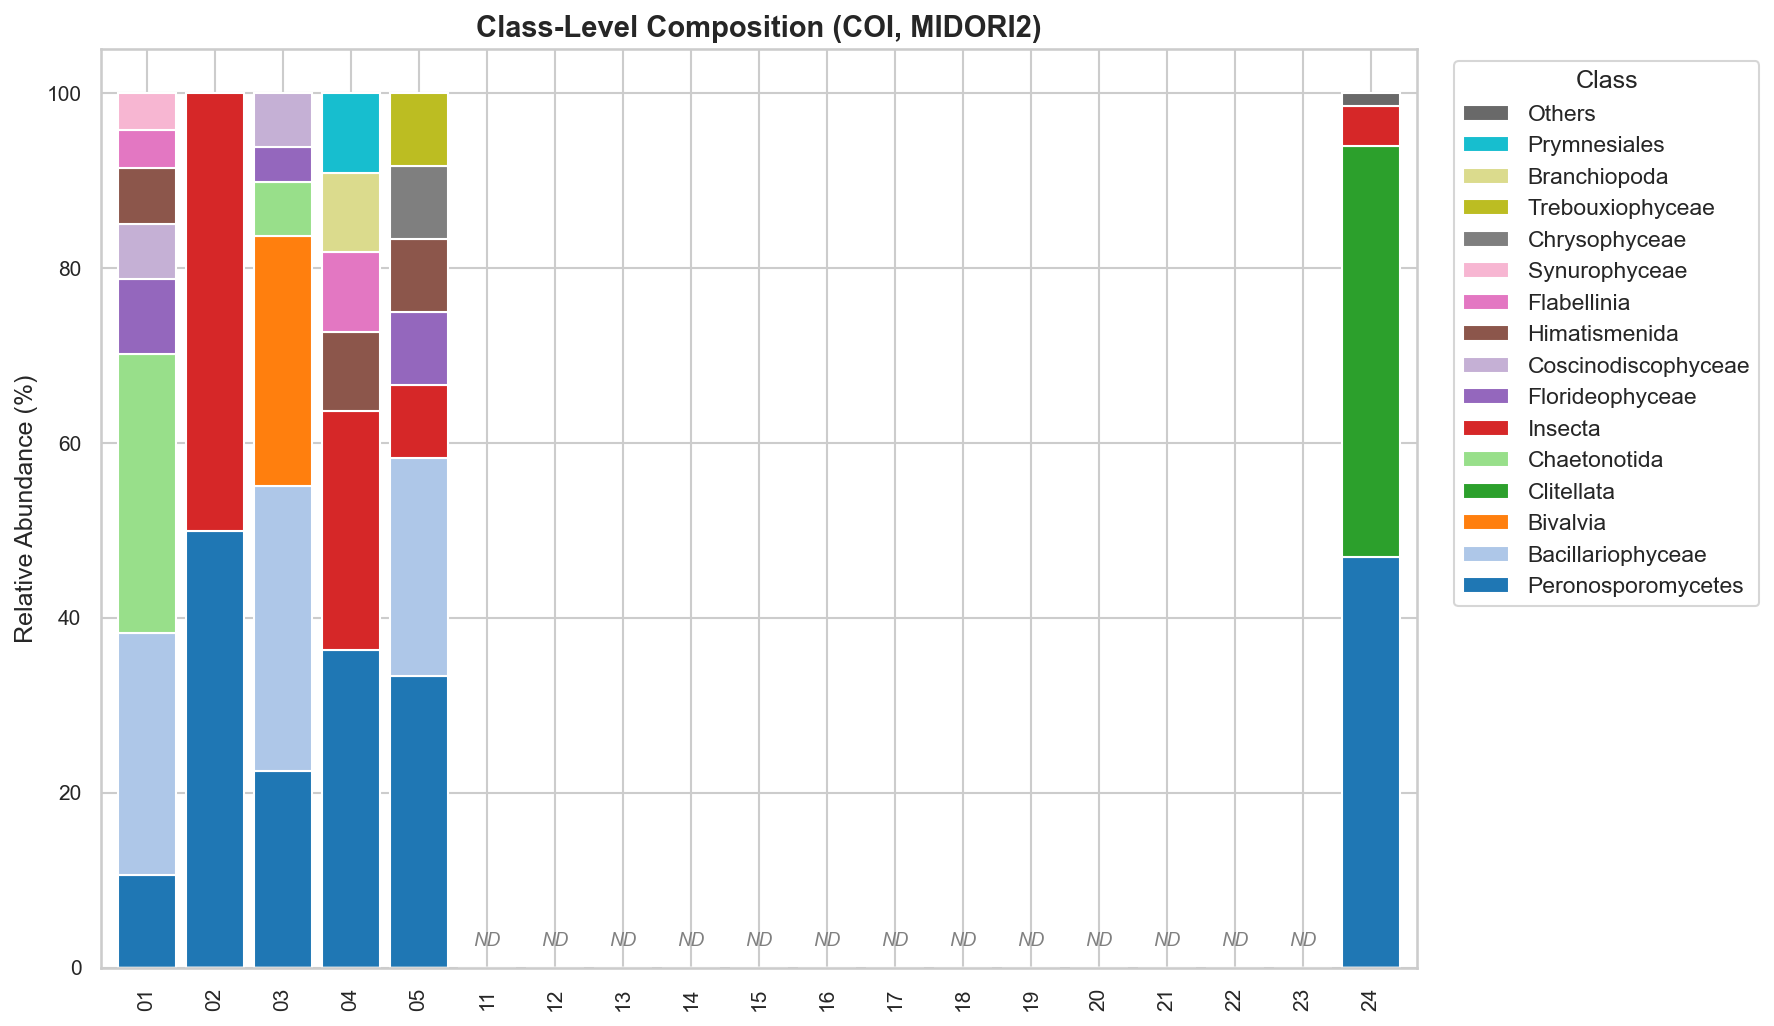

In [12]:
# Group by Class (COI)
class_col_coi = f'{prefix_coi}_Class'
df_coi[class_col_coi] = df_coi[class_col_coi].fillna('Unassigned')
class_coi = df_coi.groupby(class_col_coi)[sample_cols_coi].sum()
class_coi = class_coi.drop('Unassigned', errors='ignore')

# Sort and Top 15
class_coi['Total'] = class_coi.sum(axis=1)
class_coi = class_coi.sort_values('Total', ascending=False)
top_classes_coi = class_coi.head(15).index

# Prepare Data
plot_cls_coi = class_coi.loc[top_classes_coi].drop(columns='Total')
others_cls_coi = class_coi.loc[~class_coi.index.isin(top_classes_coi)].drop(columns='Total').sum()
plot_cls_coi.loc['Others'] = others_cls_coi

# Custom color logic
num_colors_coi = len(plot_cls_coi)
colors_coi = cm.tab20(np.linspace(0, 1, num_colors_coi))
custom_colors_coi = []
for i, cls_name in enumerate(plot_cls_coi.index):
    if cls_name == 'Unassigned':
        custom_colors_coi.append('#D3D3D3')
    elif cls_name == 'Others':
        custom_colors_coi.append('#696969')
    else:
        custom_colors_coi.append(colors_coi[i])

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
plot_cls_coi.columns = clean_sample_names(plot_cls_coi.columns)
plot_cls_coi = plot_cls_coi.div(plot_cls_coi.sum(axis=0), axis=1) * 100  # normalize to %
plot_cls_coi = plot_cls_coi.fillna(0)
plot_cls_coi.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, color=custom_colors_coi)

ax.set_title(f'Class-Level Composition (COI, {prefix_coi})', fontweight='bold')
ax.set_ylabel('Relative Abundance (%)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), bbox_to_anchor=(1.02, 1), loc='upper left', title='Class')

# Mark samples with no assigned taxa
for _idx, _sample in enumerate(plot_cls_coi.columns):
    if plot_cls_coi[_sample].sum() == 0:
        ax.text(_idx, 2, 'ND', ha='center', va='bottom',
                fontsize=9, color='gray', fontstyle='italic')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## B.2 Order-Level Breakdown (COI)
Order-level community composition for the COI marker.

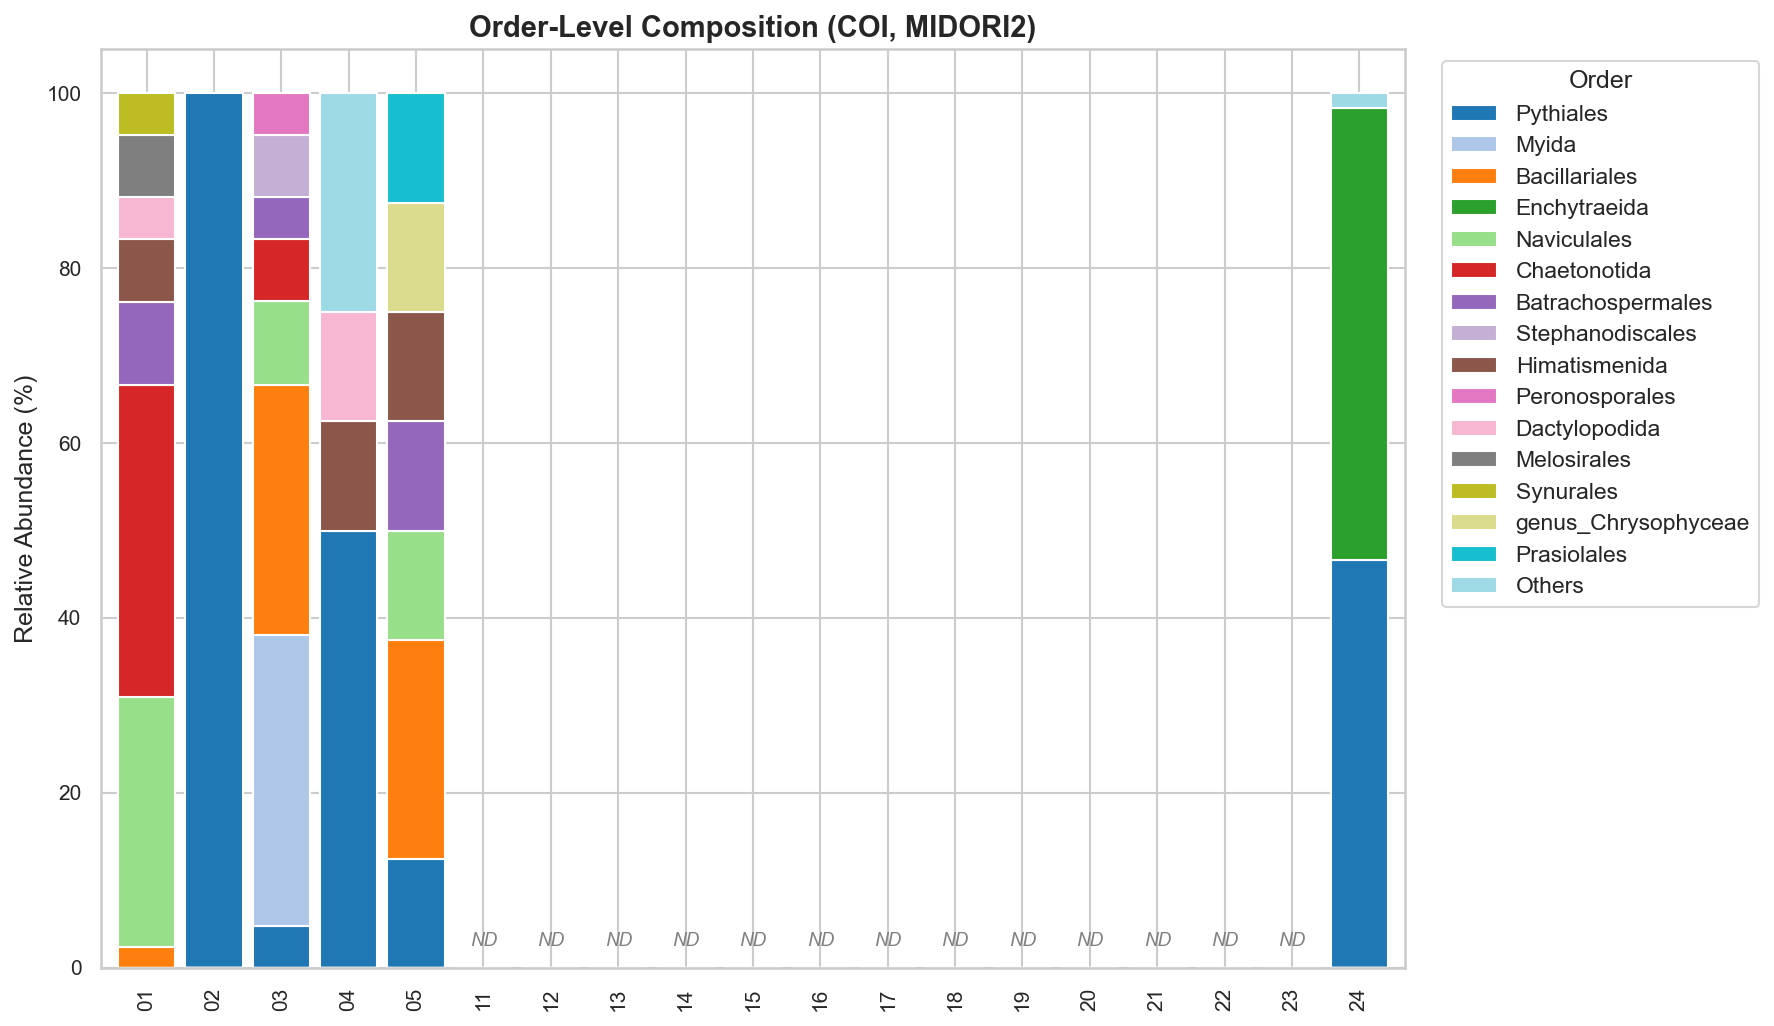

In [13]:
order_col_coi = f'{prefix_coi}_Order'
df_coi[order_col_coi] = df_coi[order_col_coi].fillna('Unassigned')
order_coi = df_coi.groupby(order_col_coi)[sample_cols_coi].sum()
order_coi = order_coi.drop('Unassigned', errors='ignore')

order_coi['Total'] = order_coi.sum(axis=1)
order_coi = order_coi.sort_values('Total', ascending=False)
top_orders_coi = order_coi.head(15).index

plot_ord_coi = order_coi.loc[top_orders_coi].drop(columns='Total')
others_ord_coi = order_coi.loc[~order_coi.index.isin(top_orders_coi)].drop(columns='Total').sum()
plot_ord_coi.loc['Others'] = others_ord_coi

fig, ax = plt.subplots(figsize=(12, 7))
plot_ord_coi.columns = clean_sample_names(plot_ord_coi.columns)
plot_ord_coi = plot_ord_coi.div(plot_ord_coi.sum(axis=0), axis=1) * 100  # normalize to %
plot_ord_coi = plot_ord_coi.fillna(0)
plot_ord_coi.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, cmap='tab20')

ax.set_title(f'Order-Level Composition (COI, {prefix_coi})', fontweight='bold')
ax.set_ylabel('Relative Abundance (%)')
ax.legend(title='Order', bbox_to_anchor=(1.02, 1), loc='upper left')

for _idx, _sample in enumerate(plot_ord_coi.columns):
    if plot_ord_coi[_sample].sum() == 0:
        ax.text(_idx, 2, 'ND', ha='center', va='bottom',
                fontsize=9, color='gray', fontstyle='italic')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## B.3 Genus-Level Top 20 (COI)
Top genera detected by the COI marker with confidence annotations.

C:\Users\ilias\AppData\Local\Temp\ipykernel_26612\2663013595.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genera_coi['Total'], y=top_genera_coi.index, palette='viridis', ax=ax)


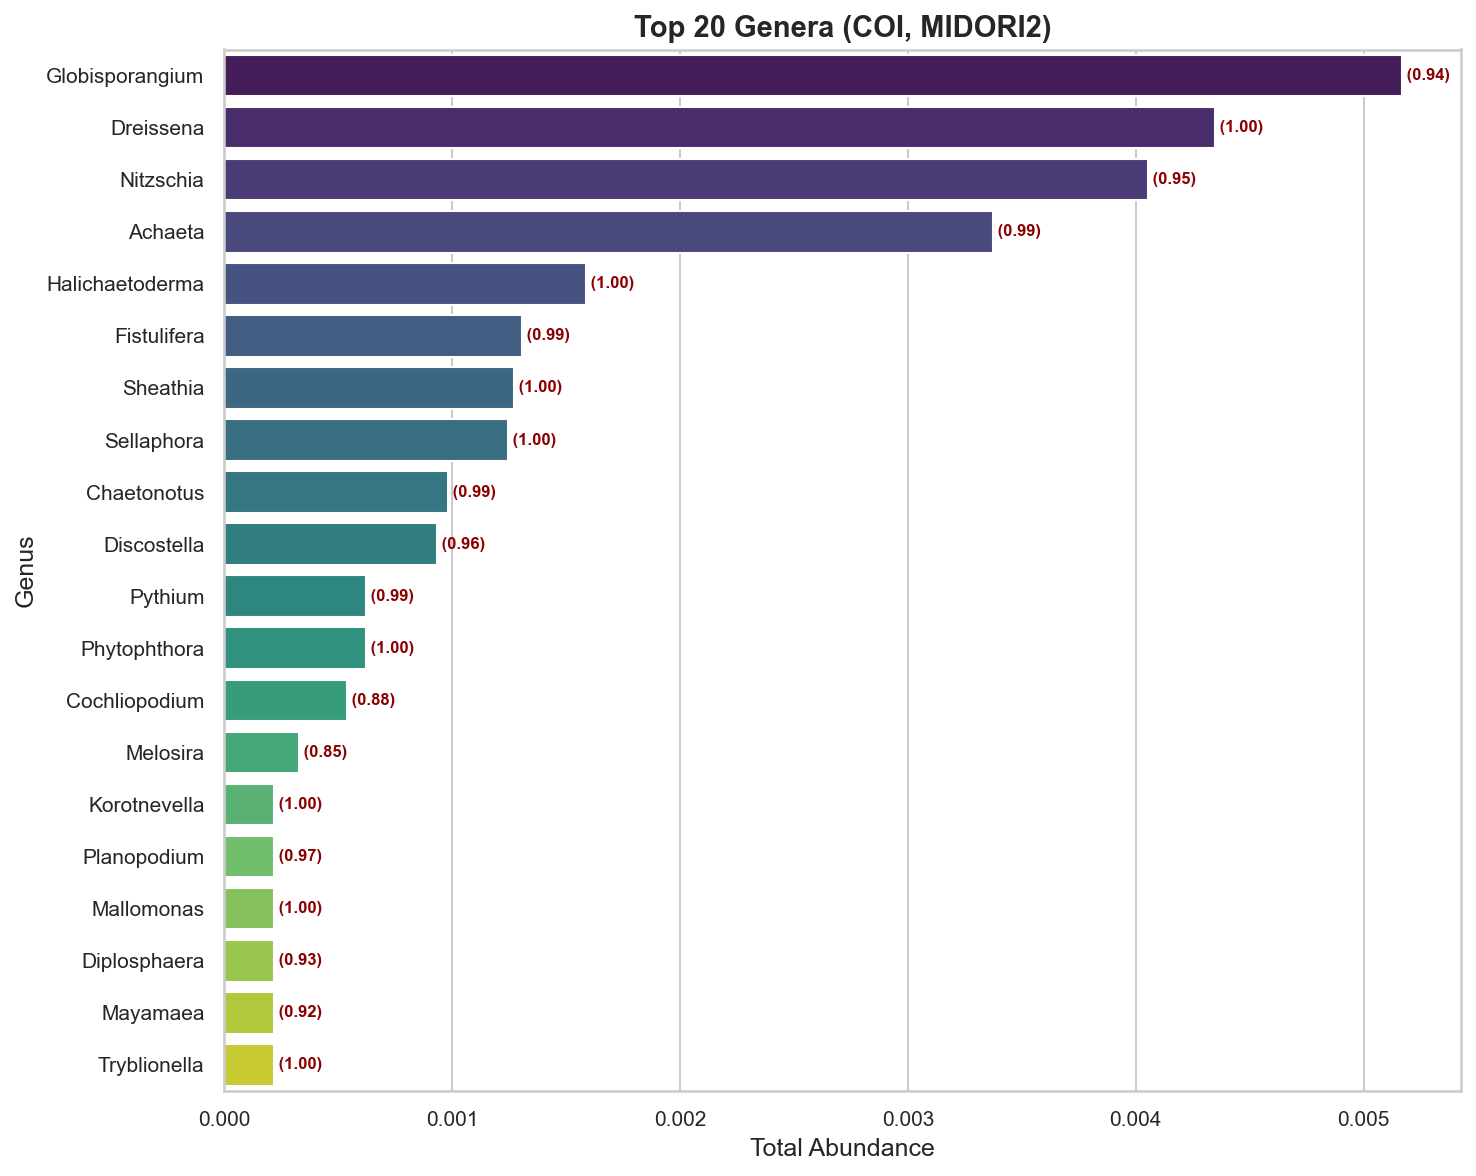

In [14]:
genus_col_coi = f'{prefix_coi}_Genus'
df_coi[genus_col_coi] = df_coi[genus_col_coi].fillna('Unassigned')
genus_coi = df_coi.groupby(genus_col_coi)[sample_cols_coi].sum()
genus_coi = genus_coi.drop('Unassigned', errors='ignore')
genus_coi['Total'] = genus_coi.sum(axis=1)
genus_coi = genus_coi.sort_values('Total', ascending=False)

top_genera_coi = genus_coi.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top_genera_coi['Total'], y=top_genera_coi.index, palette='viridis', ax=ax)
ax.set_title(f'Top 20 Genera (COI, {prefix_coi})', fontweight='bold')
ax.set_xlabel('Total Abundance')
ax.set_ylabel('Genus')

_genus_conf_col = f'{prefix_coi}_Genus_Conf'
if _genus_conf_col in df_coi.columns:
    for _i, _genus_name in enumerate(top_genera_coi.index):
        _mask = df_coi[genus_col_coi] == _genus_name
        _cvals = pd.to_numeric(df_coi.loc[_mask, _genus_conf_col], errors='coerce').dropna()
        if len(_cvals) > 0:
            _mc = _cvals.mean()
            ax.text(top_genera_coi['Total'].iloc[_i], _i, f' ({_mc:.2f})',
                    va='center', ha='left', fontsize=8, color='darkred', fontweight='bold')
plt.tight_layout()
plt.show()

### Top 20 Genera by Abundance — All Confidences (COI)
Same marker but showing ALL genus assignments regardless of confidence, ranked by abundance. Bars are color-coded by mean confidence level.

In [ ]:
# Top 20 Genera by ABUNDANCE (including low-confidence assignments)
genus_raw_col = f'{prefix_coi}_Genus_Raw'
genus_raw_conf_col = f'{prefix_coi}_Genus_Raw_Conf'

if genus_raw_col in df_coi.columns:
    df_tmp = df_coi.copy()
    df_tmp[genus_raw_col] = df_tmp[genus_raw_col].fillna('Unassigned')
    genus_abund = df_tmp.groupby(genus_raw_col)[sample_cols_coi].sum()
    genus_abund = genus_abund.drop('Unassigned', errors='ignore')
    genus_abund['Total'] = genus_abund.sum(axis=1)
    genus_abund = genus_abund.sort_values('Total', ascending=False)
    top20 = genus_abund.head(20)

    # Compute mean confidence per genus (raw)
    raw_conf = {}
    for genus in top20.index:
        mask = df_tmp[genus_raw_col] == genus
        vals = pd.to_numeric(df_tmp.loc[mask, genus_raw_conf_col], errors='coerce').dropna()
        raw_conf[genus] = vals.mean() if len(vals) > 0 else None

    fig, ax = plt.subplots(figsize=(11, 8))
    colors = []
    for genus in top20.index:
        c = raw_conf.get(genus)
        if c is None:
            colors.append('#999999')
        elif c >= 0.8:
            colors.append('#2d8a4e')
        elif c >= 0.5:
            colors.append('#e6a817')
        else:
            colors.append('#c0392b')

    bars = ax.barh(range(len(top20)), top20['Total'].values[::-1], color=colors[::-1], height=0.7)
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20.index[::-1], fontsize=9)
    ax.set_xlabel('Total Abundance', fontsize=11)
    ax.set_title(f'Top 20 Genera by Abundance — All Confidences (COI, {prefix_coi})',
                 fontweight='bold', fontsize=12)

    xmax = top20['Total'].max()
    for j, genus in enumerate(top20.index[::-1]):
        c = raw_conf.get(genus)
        if c is not None:
            color = '#2d8a4e' if c >= 0.8 else '#e6a817' if c >= 0.5 else '#c0392b'
            ax.text(top20.loc[genus, 'Total'] + xmax * 0.01, j,
                    f' {c:.2f}', va='center', fontsize=9, fontweight='bold', color=color)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2d8a4e', label='\u2265 0.80 (confident)'),
        Patch(facecolor='#e6a817', label='0.50 \u2013 0.79 (moderate)'),
        Patch(facecolor='#c0392b', label='< 0.50 (low confidence)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
              title='Mean confidence', title_fontsize=9, framealpha=0.9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print(f'Column {genus_raw_col} not found — re-run regenerate_taxonomy.sh to generate raw genus columns.')

## B.4 Taxonomic Resolution Comparison: JEDI vs COI
**Comparison:** We expect the JEDI marker to have a different "Unassigned" profile than standard COI. Key questions:
1. Does the shorter JEDI fragment lead to more or fewer unassigned OTUs?
2. At which taxonomic levels do the markers diverge most?
3. Does either marker provide consistently better resolution for soil taxa?

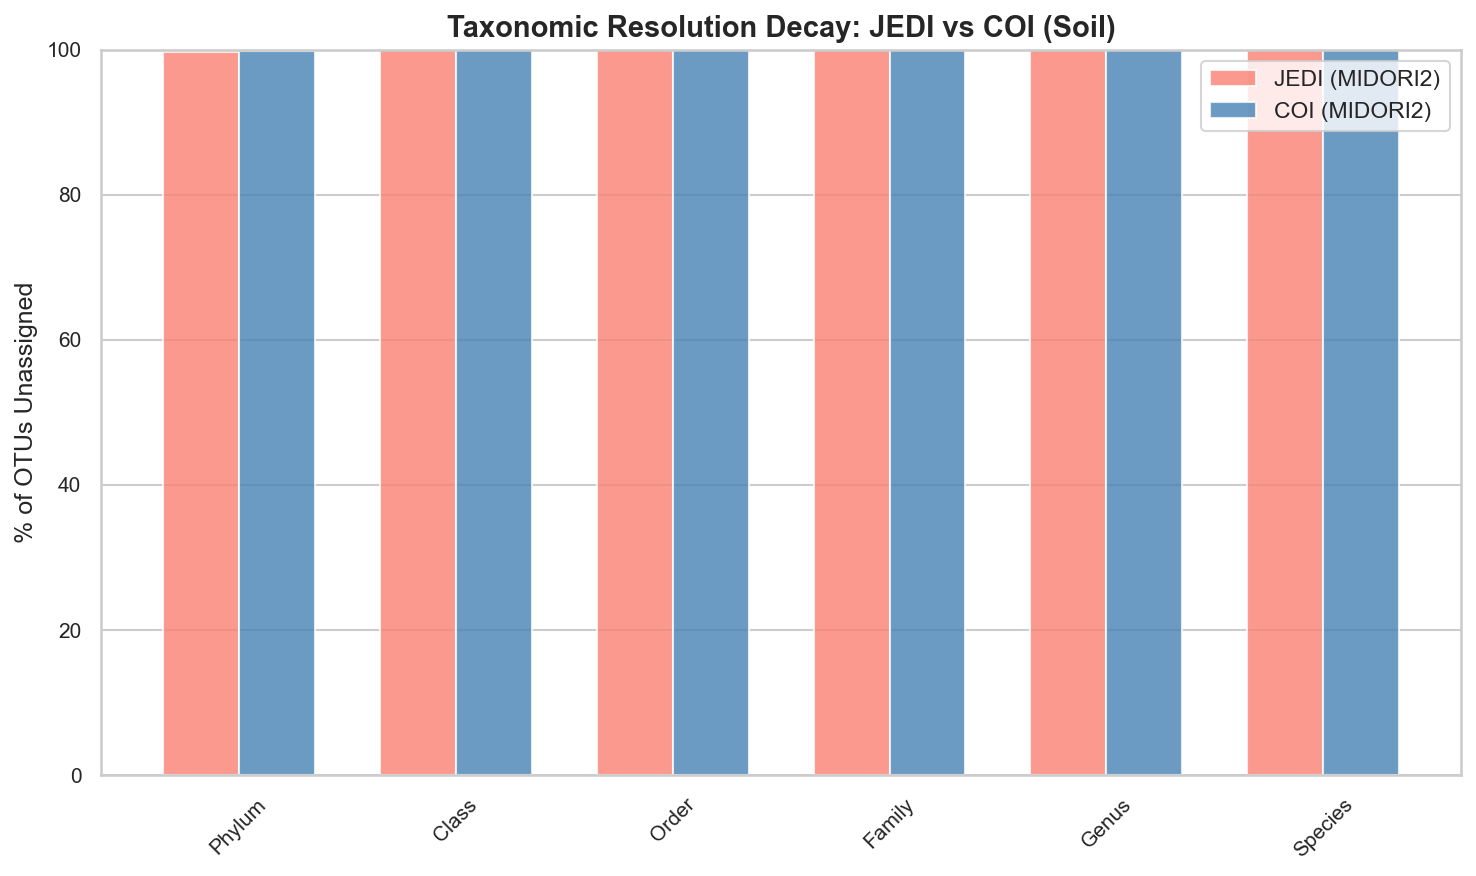

In [15]:
# Calculate % Unassigned at each level for both markers
ranks = ['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']

# Recalculate JEDI unassigned for comparison
levels_jedi = [f'{prefix_jedi}_{r}' for r in ranks]
unassigned_jedi = []
for level in levels_jedi:
    n_unassigned = df_jedi[level].isin(['Unassigned', np.nan]).sum()
    pct = (n_unassigned / len(df_jedi)) * 100
    unassigned_jedi.append(pct)

levels_coi = [f'{prefix_coi}_{r}' for r in ranks]
unassigned_coi = []
for level in levels_coi:
    n_unassigned = df_coi[level].isin(['Unassigned', np.nan]).sum()
    pct = (n_unassigned / len(df_coi)) * 100
    unassigned_coi.append(pct)

# Plot: side-by-side comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(ranks))
width = 0.35

bars1 = ax.bar(x - width/2, unassigned_jedi, width, label=f'JEDI ({prefix_jedi})', color='salmon', alpha=0.8)
bars2 = ax.bar(x + width/2, unassigned_coi, width, label=f'COI ({prefix_coi})', color='steelblue', alpha=0.8)

ax.set_title('Taxonomic Resolution Decay: JEDI vs COI (Soil)', fontweight='bold')
ax.set_ylabel('% of OTUs Unassigned')
ax.set_xticks(x)
ax.set_xticklabels(ranks, rotation=45)
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.show()

## B.5 Forensics: Manual BLAST Identification
BLAST validation of the top OTUs provides ground-truth species identification beyond what SINTAX can offer with the MIDORI2 database.
1. **Concordance Check:** Do BLAST results confirm what SINTAX assigned?
2. **Novel Detections:** BLAST may identify species that SINTAX labeled as "Unassigned" due to the confidence threshold.
3. **Database Artifacts:** Look for unexpected species that indicate database gaps rather than true detections.

In [ ]:
def parse_blast_file(filepath):
    """Parses the custom text output from script 6_blast_top_otus.py"""
    data = []
    try:
        with open(filepath, 'r') as f:
            lines = f.readlines()
        start_reading = False
        for line in lines:
            if line.startswith('---'):
                start_reading = True
                continue
            if not start_reading or not line.strip(): continue
            parts = line.split('|')
            if len(parts) >= 4:
                otu_id = parts[0].strip()
                species = parts[2].strip()
                identity_str = parts[3].strip().replace('%', '')
                try:
                    reads = float(parts[1].strip())
                    identity = float(identity_str) if identity_str and identity_str != '-' else None
                    data.append({'OTU': otu_id, 'Species': species, 'Abundance': reads, 'Identity': identity})
                except: continue
    except FileNotFoundError:
        print("BLAST file not found.")
        return pd.DataFrame()
    return pd.DataFrame(data)

df_blast = parse_blast_file('out/Soil_eDNA_JEDI_COI_14_01_26/blast_results/blast_top10_JEDI.txt')
if not df_blast.empty:
    df_blast = df_blast.sort_values('Abundance', ascending=True)

    # Build clean labels: Species (short OTU suffix)
    labels = []
    for _, row in df_blast.iterrows():
        otu_short = row['OTU'].split('_')[-1]  # e.g. "005421"
        labels.append(f"{row['Species']}  [{otu_short}]")
    df_blast['Label'] = labels

    # Color by identity tier
    colors = []
    for _, row in df_blast.iterrows():
        if row['Identity'] is None:
            colors.append('#999999')
        elif row['Identity'] >= 97:
            colors.append('#2d8a4e')   # species-level green
        elif row['Identity'] >= 90:
            colors.append('#e6a817')   # genus-level amber
        else:
            colors.append('#c0392b')   # uncertain red

    fig, ax = plt.subplots(figsize=(11, max(3, len(df_blast) * 0.55)))
    bars = ax.barh(range(len(df_blast)), df_blast['Abundance'].values,
                   color=colors, edgecolor='white', height=0.7)

    ax.set_yticks(range(len(df_blast)))
    ax.set_yticklabels(df_blast['Label'].values, fontsize=9)
    ax.set_xlabel('Relative Abundance', fontsize=11)
    ax.set_title('Top JEDI OTUs — Closest Species Match (BLAST vs NCBI)', fontweight='bold', fontsize=13, pad=12)

    # Annotate identity at bar end
    xmax = df_blast['Abundance'].max()
    for j, (_, row) in enumerate(df_blast.iterrows()):
        if row['Identity'] is not None:
            ax.text(row['Abundance'] + xmax * 0.015, j,
                    f"{row['Identity']:.1f}%", va='center',
                    fontsize=9, fontweight='bold', color=colors[j])
        else:
            ax.text(row['Abundance'] + xmax * 0.015, j,
                    "N/A", va='center', fontsize=9, color='#999999')

    # Add legend for identity tiers
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2d8a4e', label='\u2265 97% (species)'),
        Patch(facecolor='#e6a817', label='90-97% (genus)'),
        Patch(facecolor='#c0392b', label='< 90% (uncertain)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
              title='Identity level', title_fontsize=9, framealpha=0.9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, xmax * 1.18)

    plt.tight_layout()
    plt.show()
else:
    print("No valid BLAST data found to plot.")

df_blast = parse_blast_file('out/Soil_eDNA_JEDI_COI_14_01_26/blast_results/blast_top10_COI.txt')
if not df_blast.empty:
    df_blast = df_blast.sort_values('Abundance', ascending=True)

    # Build clean labels: Species (short OTU suffix)
    labels = []
    for _, row in df_blast.iterrows():
        otu_short = row['OTU'].split('_')[-1]  # e.g. "005421"
        labels.append(f"{row['Species']}  [{otu_short}]")
    df_blast['Label'] = labels

    # Color by identity tier
    colors = []
    for _, row in df_blast.iterrows():
        if row['Identity'] is None:
            colors.append('#999999')
        elif row['Identity'] >= 97:
            colors.append('#2d8a4e')   # species-level green
        elif row['Identity'] >= 90:
            colors.append('#e6a817')   # genus-level amber
        else:
            colors.append('#c0392b')   # uncertain red

    fig, ax = plt.subplots(figsize=(11, max(3, len(df_blast) * 0.55)))
    bars = ax.barh(range(len(df_blast)), df_blast['Abundance'].values,
                   color=colors, edgecolor='white', height=0.7)

    ax.set_yticks(range(len(df_blast)))
    ax.set_yticklabels(df_blast['Label'].values, fontsize=9)
    ax.set_xlabel('Relative Abundance', fontsize=11)
    ax.set_title('Top COI OTUs — Closest Species Match (BLAST vs NCBI)', fontweight='bold', fontsize=13, pad=12)

    # Annotate identity at bar end
    xmax = df_blast['Abundance'].max()
    for j, (_, row) in enumerate(df_blast.iterrows()):
        if row['Identity'] is not None:
            ax.text(row['Abundance'] + xmax * 0.015, j,
                    f"{row['Identity']:.1f}%", va='center',
                    fontsize=9, fontweight='bold', color=colors[j])
        else:
            ax.text(row['Abundance'] + xmax * 0.015, j,
                    "N/A", va='center', fontsize=9, color='#999999')

    # Add legend for identity tiers
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2d8a4e', label='\u2265 97% (species)'),
        Patch(facecolor='#e6a817', label='90-97% (genus)'),
        Patch(facecolor='#c0392b', label='< 90% (uncertain)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
              title='Identity level', title_fontsize=9, framealpha=0.9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, xmax * 1.18)

    plt.tight_layout()
    plt.show()
else:
    print("No valid BLAST data found to plot.")

---
## Part C: Non-Metazoan Detections
Examine non-metazoan eukaryotes detected by both markers.

In [17]:
for label, df, pfx, sample_cols in [("JEDI", df_jedi, prefix_jedi, sample_cols_jedi),
                                      ("COI", df_coi, prefix_coi, sample_cols_coi)]:
    class_col = f'{pfx}_Class'
    genus_col = f'{pfx}_Genus'

    non_metazoan = df[
        (~df[class_col].isin(['Metazoa', 'Unassigned', '', np.nan])) &
        (df[class_col].notna())
    ]

    if len(non_metazoan) > 0:
        print(f"\n{'='*60}")
        print(f"  {label}: {len(non_metazoan)} non-Metazoan OTUs ({100*len(non_metazoan)/len(df):.1f}%)")
        print(f"{'='*60}")

        non_meta_class = non_metazoan.groupby(class_col)[sample_cols].sum()
        non_meta_class['Total'] = non_meta_class.sum(axis=1)
        non_meta_class = non_meta_class.sort_values('Total', ascending=False)
        print(f"\nNon-Metazoan Classes:")
        for cls, row in non_meta_class.head(10).iterrows():
            print(f"  {cls}: {row['Total']:.4f}")

        non_meta_genus = non_metazoan.groupby(genus_col)[sample_cols].sum()
        non_meta_genus['Total'] = non_meta_genus.sum(axis=1)
        non_meta_genus = non_meta_genus.sort_values('Total', ascending=False)
        print(f"\nTop 10 non-Metazoan Genera:")
        for gen, row in non_meta_genus.head(10).iterrows():
            print(f"  {gen}: {row['Total']:.4f}")
    else:
        print(f"\n{label}: No non-Metazoan OTUs detected")


  JEDI: 4 non-Metazoan OTUs (0.0%)

Non-Metazoan Classes:
  Peronosporomycetes: 0.0193
  Himatismenida: 0.0122
  Clitellata: 0.0043

Top 10 non-Metazoan Genera:
  Unassigned: 0.0149
  Cochliopodium: 0.0122
  Achaeta: 0.0043
  Globisporangium: 0.0043

  COI: 65 non-Metazoan OTUs (0.1%)

Non-Metazoan Classes:
  Peronosporomycetes: 0.0102
  Bacillariophyceae: 0.0070
  Bivalvia: 0.0043
  Clitellata: 0.0034
  Chaetonotida: 0.0026
  Insecta: 0.0023
  Florideophyceae: 0.0013
  Coscinodiscophyceae: 0.0013
  Himatismenida: 0.0008
  Flabellinia: 0.0004

Top 10 non-Metazoan Genera:
  Unassigned: 0.0066
  Globisporangium: 0.0052
  Dreissena: 0.0043
  Nitzschia: 0.0041
  Achaeta: 0.0034
  Halichaetoderma: 0.0016
  Fistulifera: 0.0013
  Sheathia: 0.0013
  Sellaphora: 0.0012
  Chaetonotus: 0.0010


---
## Part C: Computational Costs
**Summary:**
* **Bottleneck:** The clustering step (Step 3) is expected to dominate the total runtime due to the $N \times N$ comparison.
* **JEDI vs COI:** Processing time may differ between markers depending on the number of reads that pass quality filters.

Update the timing values below from the pipeline log after running: `out/logs/pipeline_*.log` → "GLOBAL PIPELINE STEPS TIMING" section.

In [18]:
# UPDATE THESE VALUES from your pipeline log after running on soil data
# Check: out/logs/pipeline_*.log → "GLOBAL PIPELINE STEPS TIMING" section
timing_data = {
    'Step': [
        '1. Preprocessing (QC)',
        '2. Marker Classification',
        '3. Clustering (JEDI + COI)',
        '4. Matrix Merging',
        '5. Taxonomy Assignment',
        '6. BLAST Validation',
        '7. Summary Generation'
    ],
    'Time_Seconds': [
        0,    # Preprocessing — update after run
        0,    # Classification
        0,    # Clustering (The bottleneck!)
        0,    # Merging
        0,    # Taxonomy
        0,    # BLAST
        0     # Summary
    ]
}

df_time = pd.DataFrame(timing_data)

if df_time['Time_Seconds'].sum() > 0:
    total_time = df_time['Time_Seconds'].sum()
    df_time['Percentage'] = (df_time['Time_Seconds'] / total_time) * 100

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = sns.barplot(x='Time_Seconds', y='Step', data=df_time, hue='Step', palette='Blues_r', ax=ax, legend=False)

    for i, v in enumerate(df_time['Time_Seconds']):
        pct = df_time.loc[i, 'Percentage']
        ax.text(v + 10, i, f"{int(v)}s ({pct:.1f}%)", va='center', fontweight='bold')

    ax.set_title(f'Pipeline Runtime Distribution (Total: {total_time/60:.0f} min)', fontweight='bold')
    ax.set_xlabel('Time (Seconds)')
    ax.set_ylabel('Pipeline Step')
    ax.grid(axis='x', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
else:
    print("Pipeline not run yet. Update the 'timing_data' dict above with actual timing from the log.")

Pipeline not run yet. Update the 'timing_data' dict above with actual timing from the log.


---
# Part D: Methodological Defense & Improvements

### 1. Error Correction Strategy
* **Problem:** Nanopore sequencing has a raw error rate of ~5-10%.
* **Solution:** We used **95% Identity Clustering**.
    * *Why?* Clustering at 97% or 99% (typical for Illumina) would have resulted in many false OTUs because every sequencing error would look like a new species.

### 2. Size Selection
* **JEDI Filter:** Reads were filtered for ~300–600 bp (target region ~460 bp). Reads outside this range are likely primer-dimers or concatemers.
* **COI Filter:** Reads were filtered for ~500–800 bp (target region ~658 bp). The stricter length requirement may explain lower COI yield in degraded soil DNA.

### 3. JEDI vs COI: Marker Choice for Soil
* **JEDI Advantage:** The shorter ~460 bp fragment is better suited for degraded soil DNA, where humic acids cause fragmentation.
* **COI Advantage:** The longer ~658 bp fragment may provide better species-level resolution when DNA quality is sufficient.
* **Recommendation:** For routine soil monitoring with Nanopore, JEDI is likely the more robust choice.

### 4. Critical Requirement: Custom Reference Database
* **The Problem:** We relied on the general-purpose MIDORI2 COI database, which lacks many local Swiss soil invertebrates.
* **The Solution (Future Work):** Build a **"Swiss Soil Fauna"** reference database by downloading COI sequences of known local species from NCBI and formatting them for SINTAX.
* **Benefit:** This would eliminate database-artifact misidentifications and allow accurate species-level identification of local soil biodiversity.

### 5. Computational Cost Optimization
* **Bottleneck:** The VSEARCH clustering step ($N \times N$ comparison) dominates runtime.